# [LAB-10] 7. [PBT] Titanic Survival (2)

## 이전 실습 내용 연결하기

In [38]:
%%capture cap
%run "./[LAB-10] 로지스틱 회귀ㅣ07-[PBT] Titanic Survival(1)(실습코드).ipynb"

## #04. 단변량 분석

### 1. 명목형 종속변수에 대한 단변량 분석

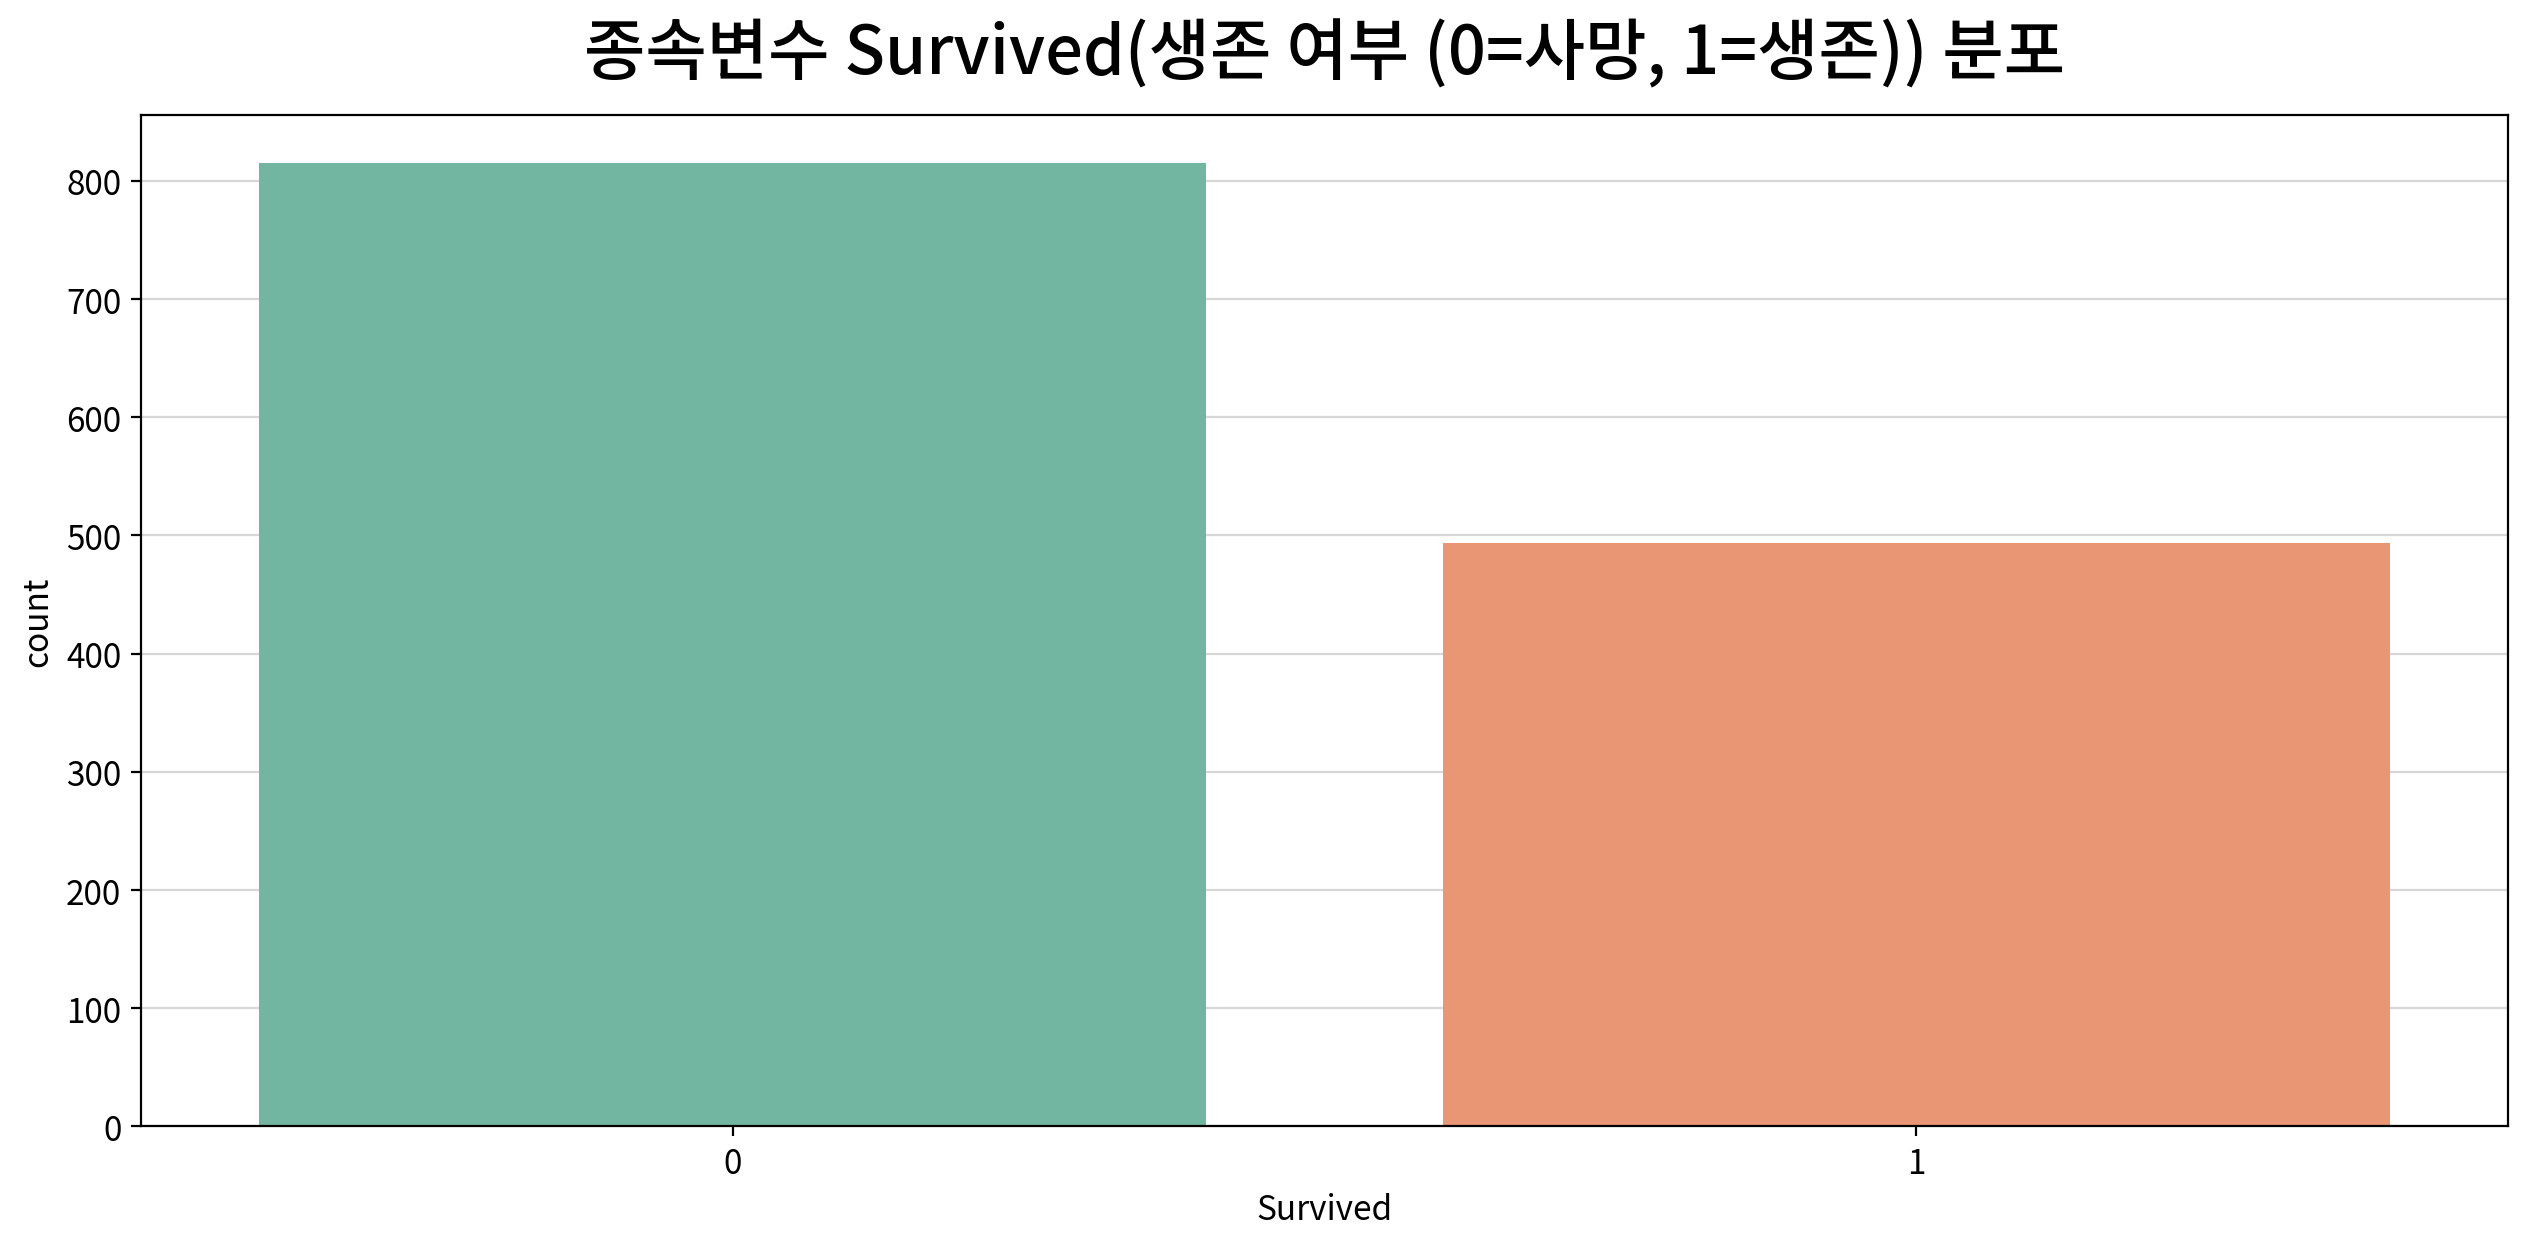

,count,unique,top,freq
Survived,1309,2,0,815


,빈도,비율
Survived,,
0,815,0.623
1,494,0.377


In [39]:
# 명목형 분포는 카운트 플롯으로 처리한다.
my_plot.countplot(data=df, x=target, hue=target, palette="Set2",
                  title=f"종속변수 {target}({column_means[target]}) 분포")

# 명목형 기술통계량
display(cat_desc[[target]].T)

# 추가적으로 빈도표 생성
freq = df[target].value_counts().rename("빈도").to_frame()
freq["비율"] = df[target].value_counts(normalize=True)
display(freq)

#### 💡 인사이트

| 점검 항목 | `Survived` 관찰값 |
|---|---|
| 범주 수 | 2 (0=사망 / 1=생존) → **이분형** 이므로 로지스틱 회귀 적용 가능 |
| 최빈 범주 | 사망 815건 (62.3%) |
| 최소 범주 | 생존 494건 (37.7%) |
| 균형 여부 | **약한 불균형** (62 : 38) |

- **정확도의 바닥값(baseline)은 62.3%** 다. 모두 "사망"이라고만 답하는 게으른 모형도 62.3%를 맞힌다.
  - 즉 정확도 70%짜리 모형은 **좋은 모형이 아니다.** 바닥값보다 8%p 나은 것에 불과하다.
  - Apple Quality의 바닥값이 50.1%였던 것과 비교해야 한다. **같은 정확도라도 데이터마다 의미가 다르다.**
- 62 : 38 정도의 불균형은 심각한 수준은 아니라 별도의 리샘플링 없이 진행하지만,
  **정확도 하나만 보지 말고 재현율·정밀도·AUC를 함께 확인**해야 한다.

### 2. 명목형 독립변수에 대한 단변량 분석

- 명목형 독립변수도 **범주별 빈도의 쏠림**을 확인한다.
  한 범주에 관측치가 지나치게 적으면 그 더미변수의 계수가 불안정해지기 때문이다.

### ▶︎ Pclass(객실 등급 (1=1등급, 2=2등급, 3=3등급)) 분포

Pclass,3,1,2
빈도,709.000,323.000,277.000
비율,0.542,0.247,0.212


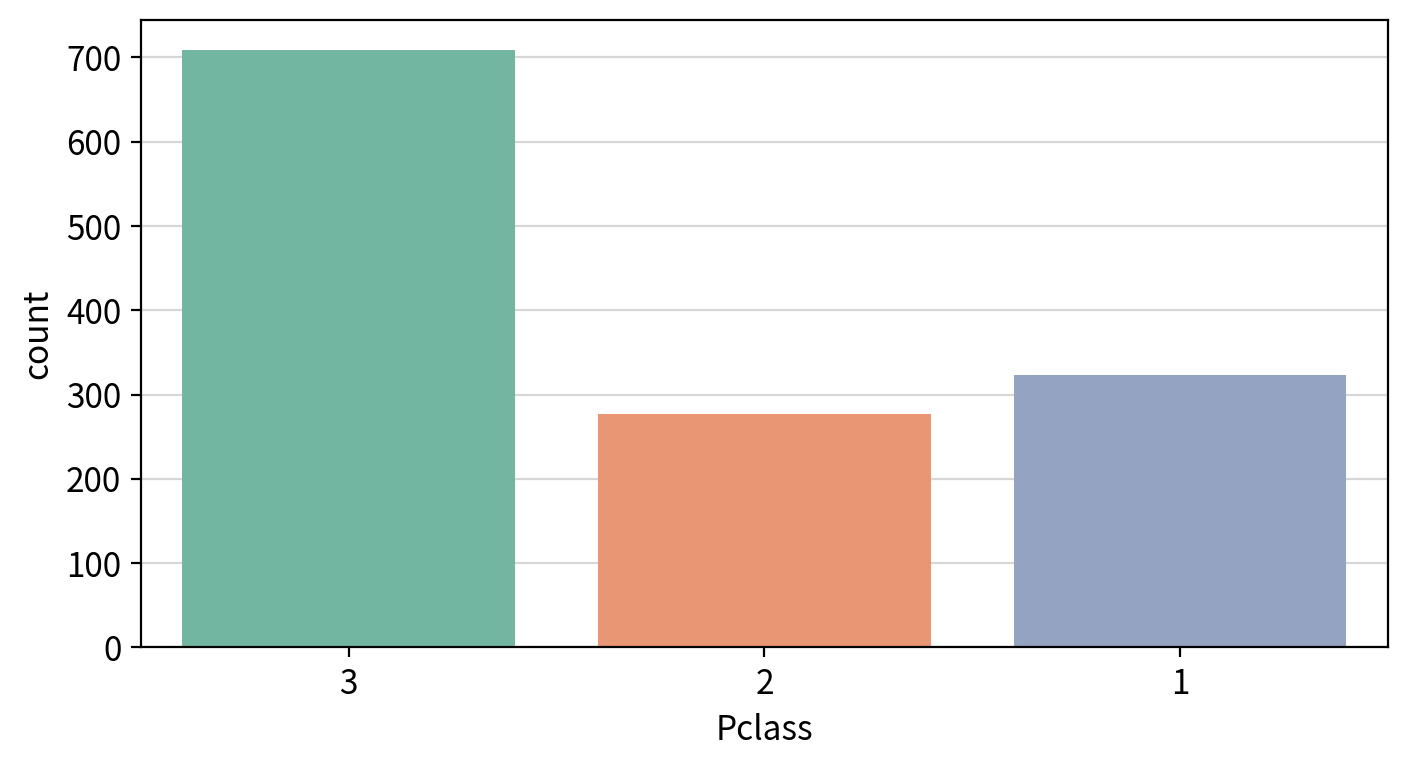

### ▶︎ Sex(성별) 분포

Sex,male,female
빈도,843.000,466.000
비율,0.644,0.356


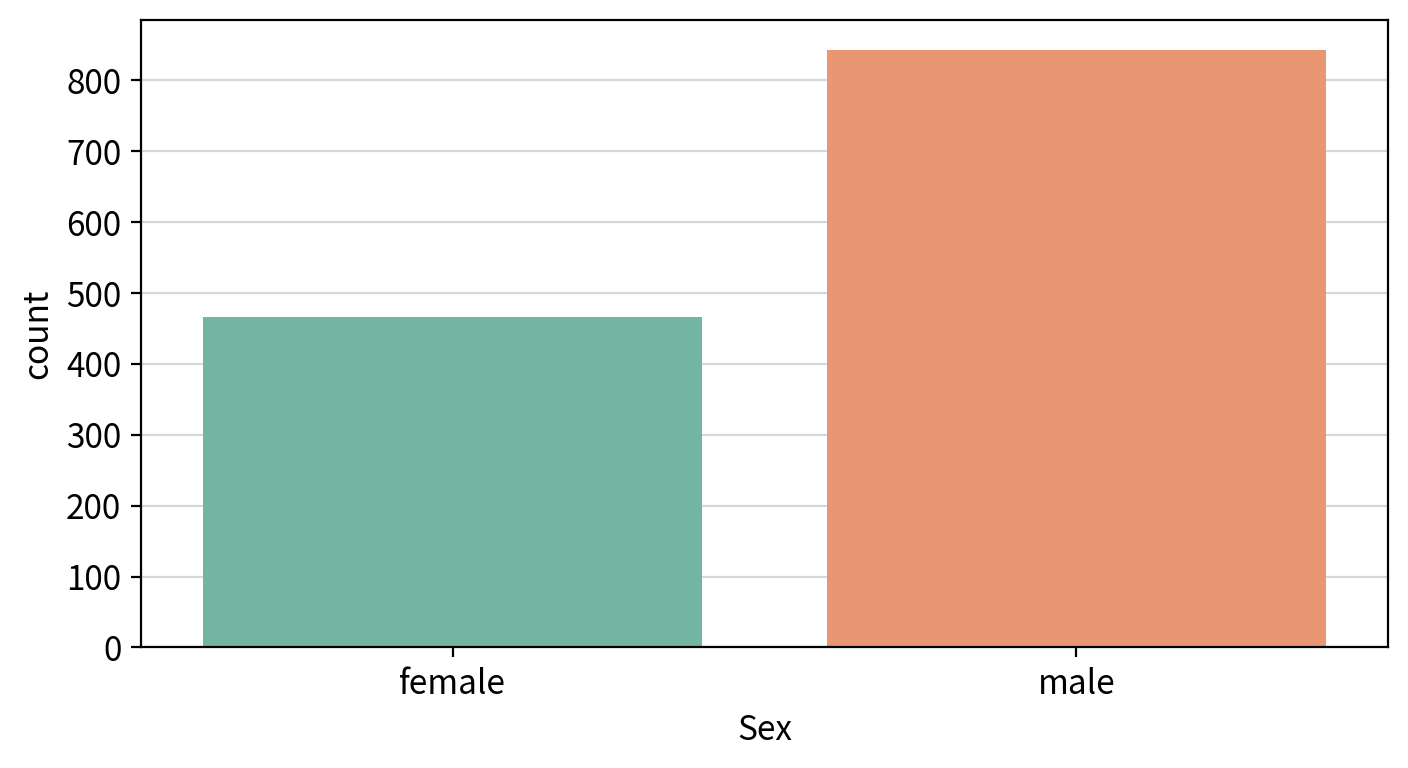

### ▶︎ Embarked(탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)) 분포

Embarked,S,C,Q
빈도,916.000,270.000,123.000
비율,0.700,0.206,0.094


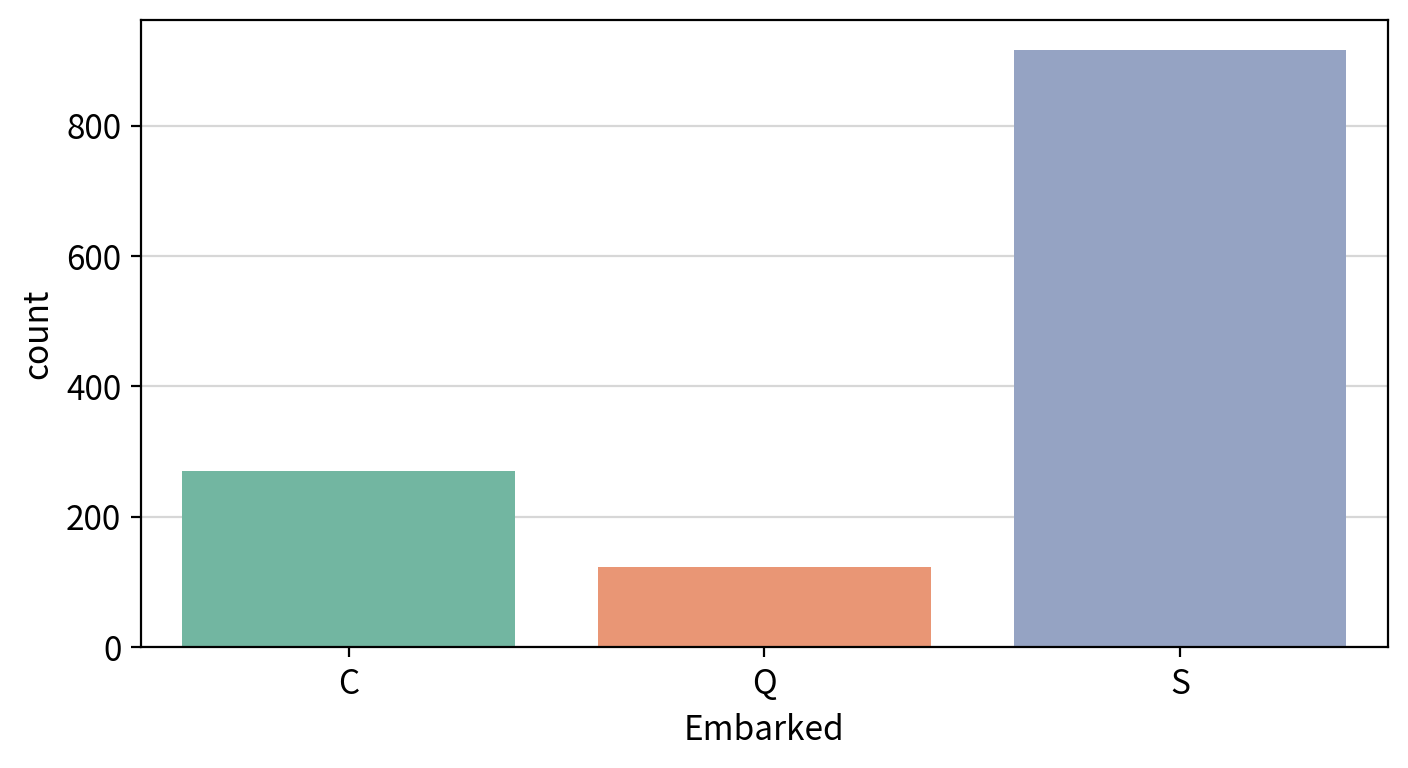

### ▶︎ Title(이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)) 분포

Title,Mr,Miss,Mrs,Master,Officer
빈도,760.000,264.000,201.000,61.000,23.000
비율,0.581,0.202,0.154,0.047,0.018


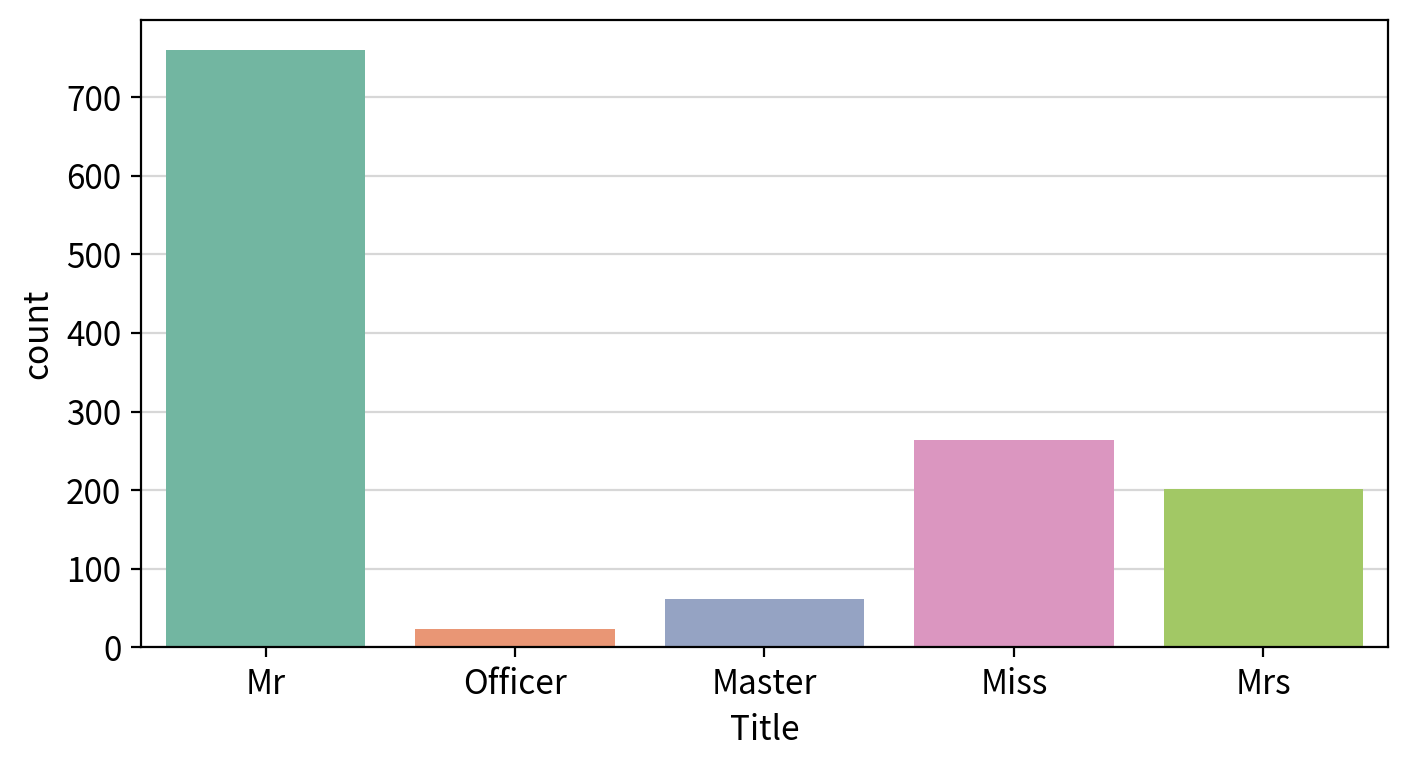

In [40]:
for n in nominal_cols:
    display(Markdown(f"### ▶︎ {n}({column_means[n]}) 분포"))
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq.T)
    
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2", width=720, height=400)

#### 💡 인사이트

| 변수 | 범주 분포 | 판단 |
|---|---|---|
| `Pclass` | 3등급 709 (54.2%) · 1등급 323 (24.7%) · 2등급 277 (21.2%) | 3등급이 절반 이상이지만 나머지도 충분 |
| `Sex` | 남성 843 (64.4%) · 여성 466 (35.6%) | 문제 없음 |
| `Embarked` | S 916 (70.0%) · C 270 (20.6%) · **Q 123 (9.4%)** | Q가 다소 적으나 100건 이상이라 사용 가능 |
| **`Title`** | Mr 760 (58.1%) · Miss 264 (20.2%) · Mrs 201 (15.4%) · Master 61 (4.7%) · **Officer 23 (1.8%)** | **`Officer`가 경계선** |

- **가장 작은 범주가 `Title = Officer`의 23건**이다. 경험칙(한 범주에 최소 10~20건)의 **하한에 걸쳐 있다.**
  - 추정은 되지만 **신뢰구간이 넓게 나올 것**을 각오해야 한다.
  - **더 잘게 나눌수록 정보는 늘지만 각 칸의 표본은 줄어든다.** 파생변수를 만들 때 항상 마주치는 교환이다.
  - 원본 호칭 18종을 그대로 썼다면 1건짜리 범주가 6개나 생겨 **아예 추정이 불가능**했을 것이다.
    5종으로 통합한 판단이 여기서 정당화된다.
- 3등급 승객이 절반을 넘는다는 사실 자체가 **타이타닉의 승객 구성**이다. 표본 편향이 아니라 모집단의 모습이다.

### 3. 연속형 독립변수에 대한 단변량 분석

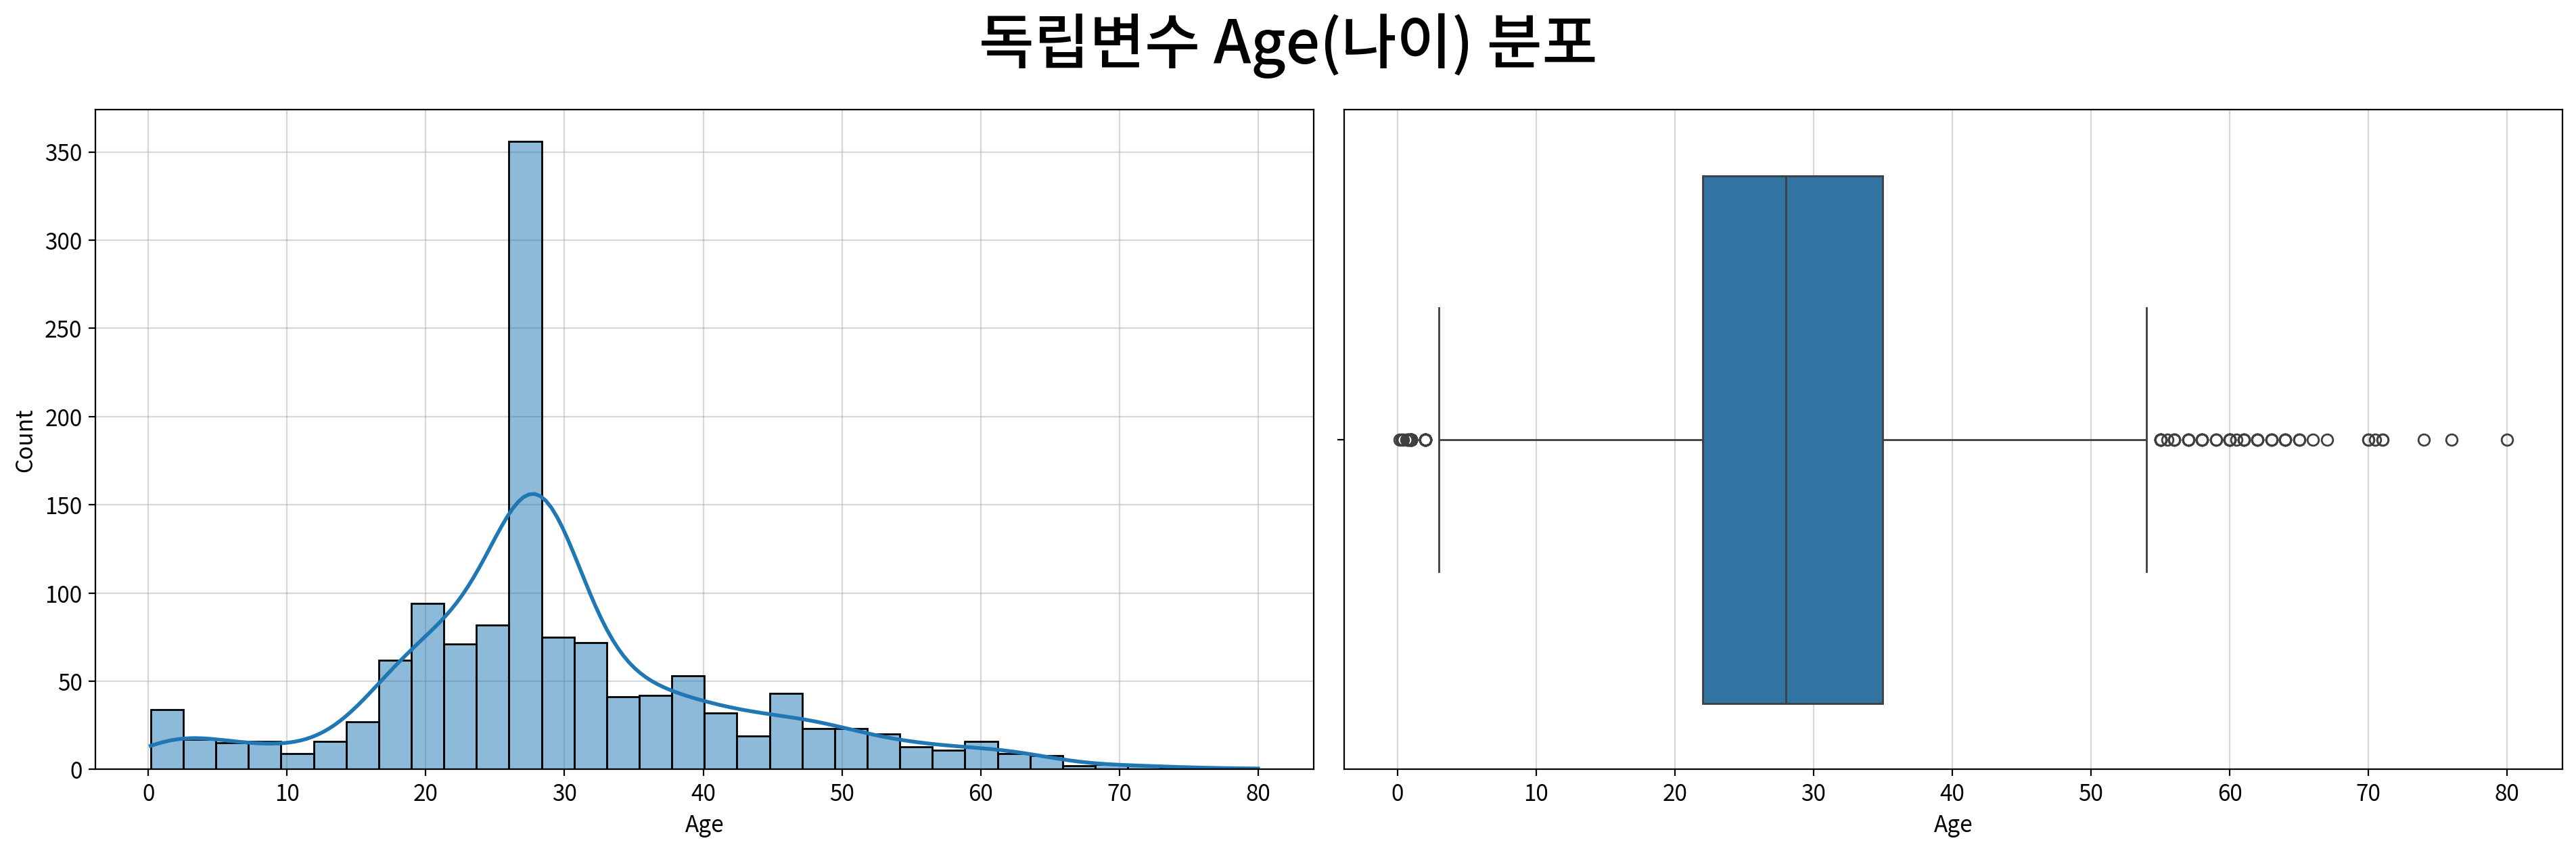

,Age
count,1309.000
mean,29.503
std,12.905
min,0.170
25%,22.000
50%,28.000
75%,35.000
max,80.000
rel_diff,0.054
rdiff_flag,similar


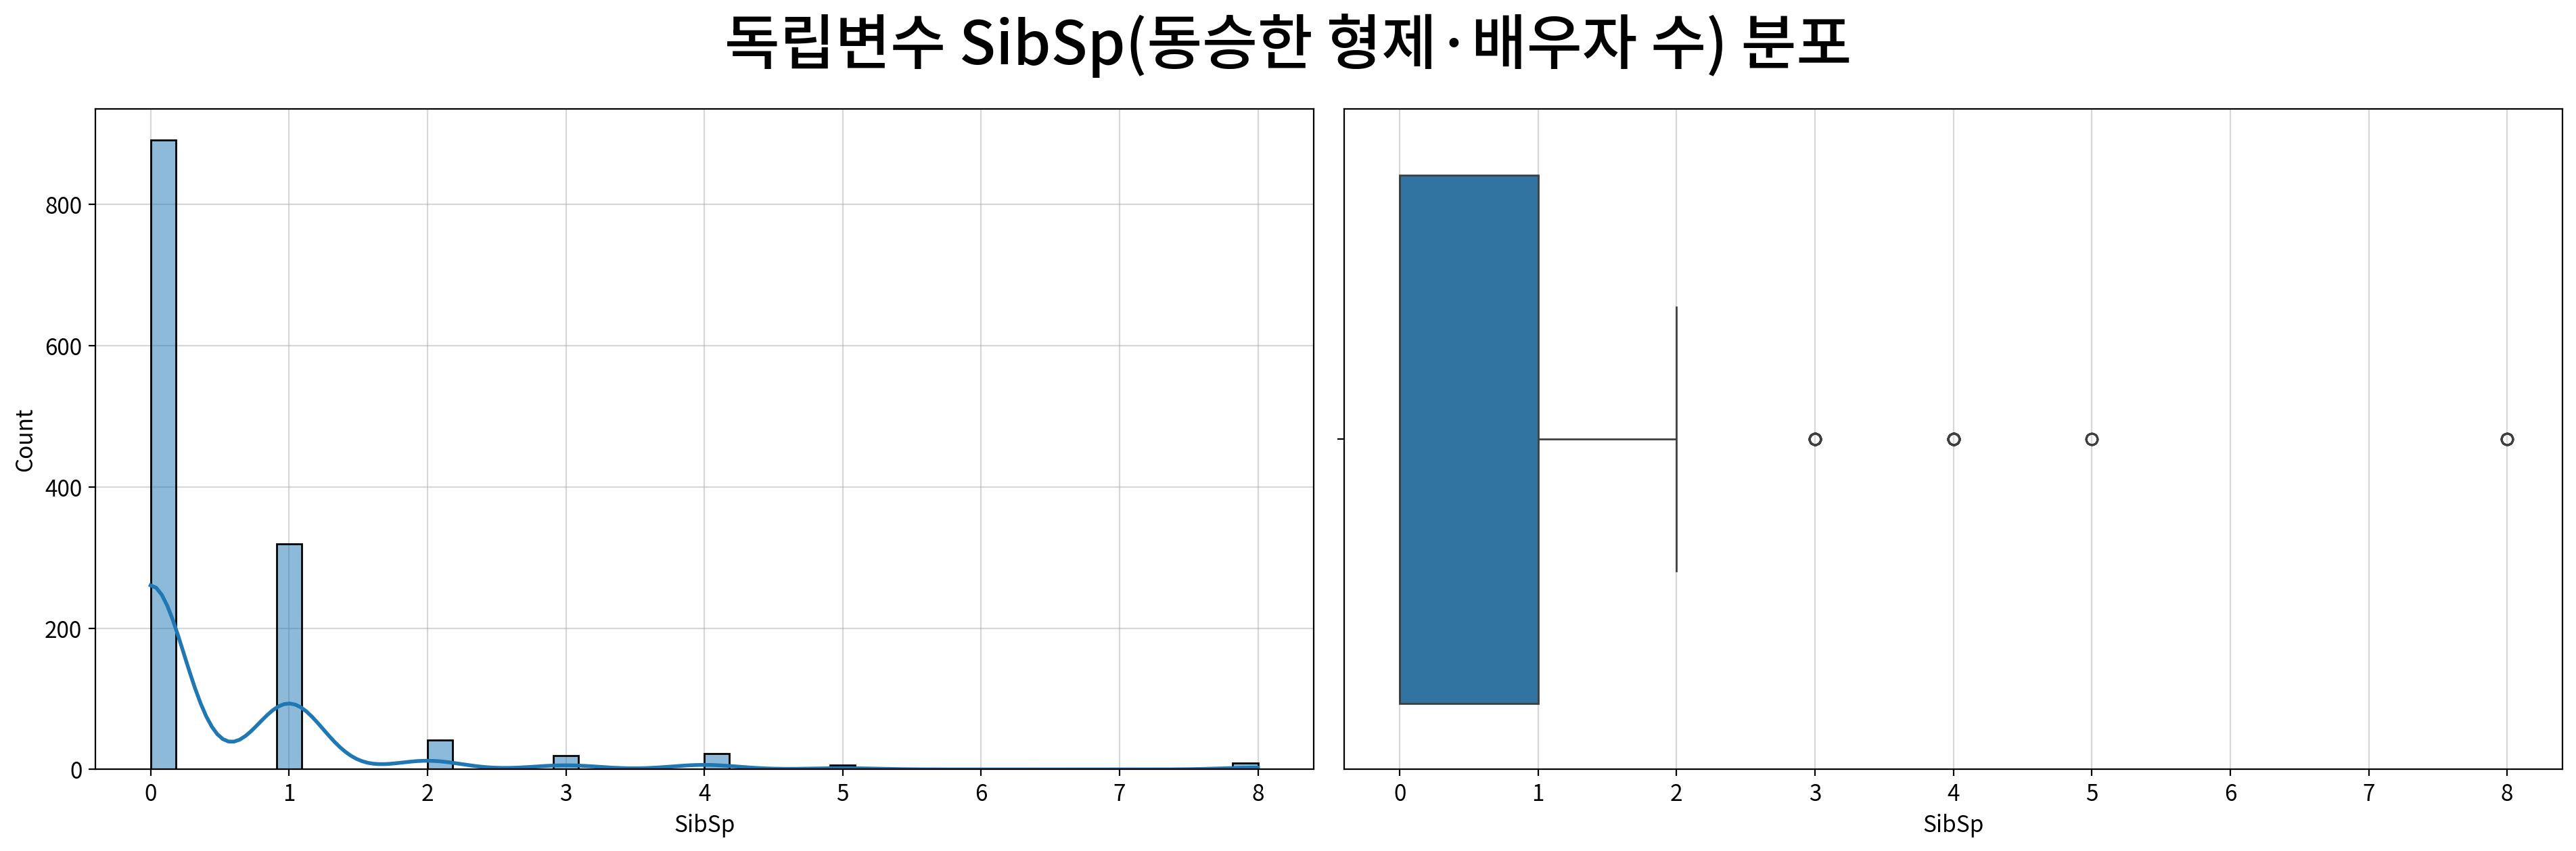

,SibSp
count,1309.000
mean,0.499
std,1.042
min,0.000
25%,0.000
50%,0.000
75%,1.000
max,8.000
rel_diff,inf
rdiff_flag,large_diff


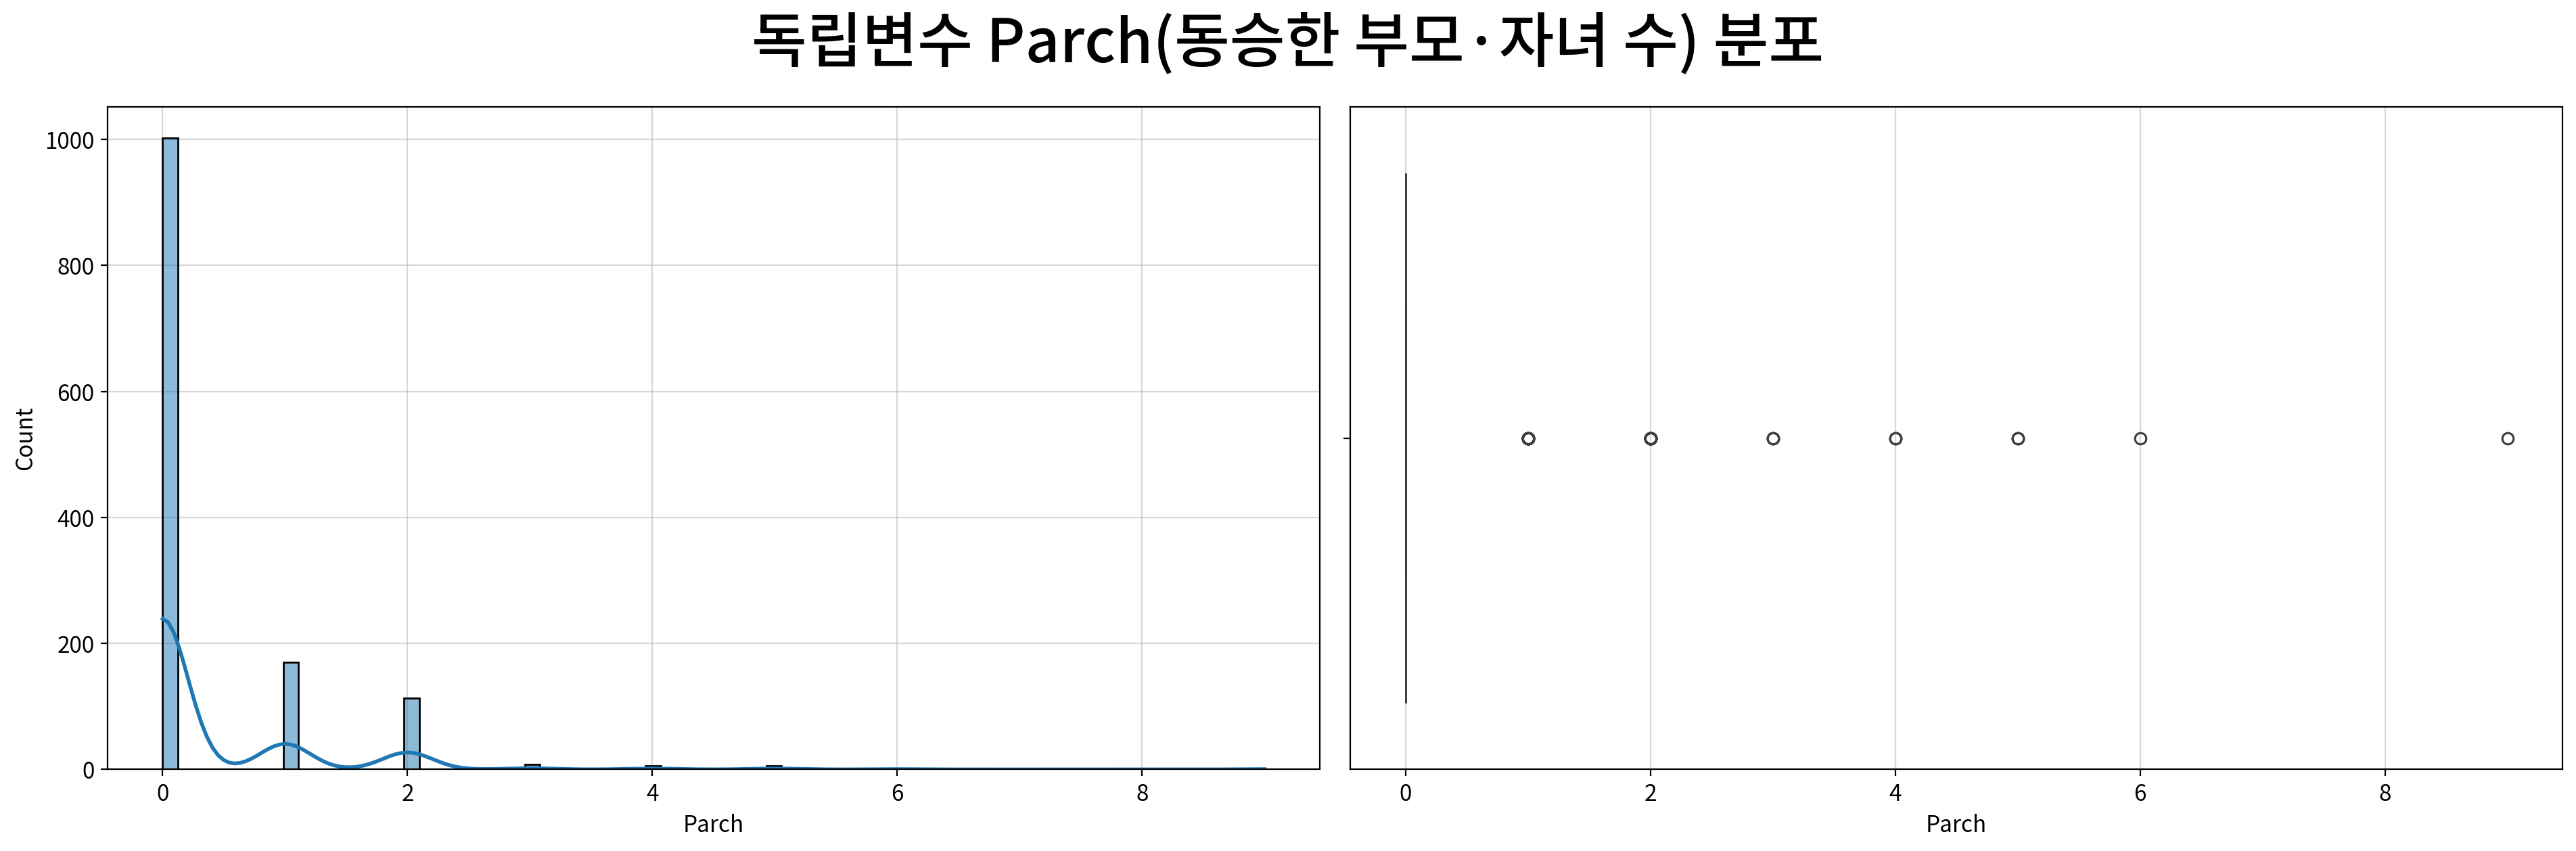

,Parch
count,1309.000
mean,0.385
std,0.866
min,0.000
25%,0.000
50%,0.000
75%,0.000
max,9.000
rel_diff,inf
rdiff_flag,large_diff


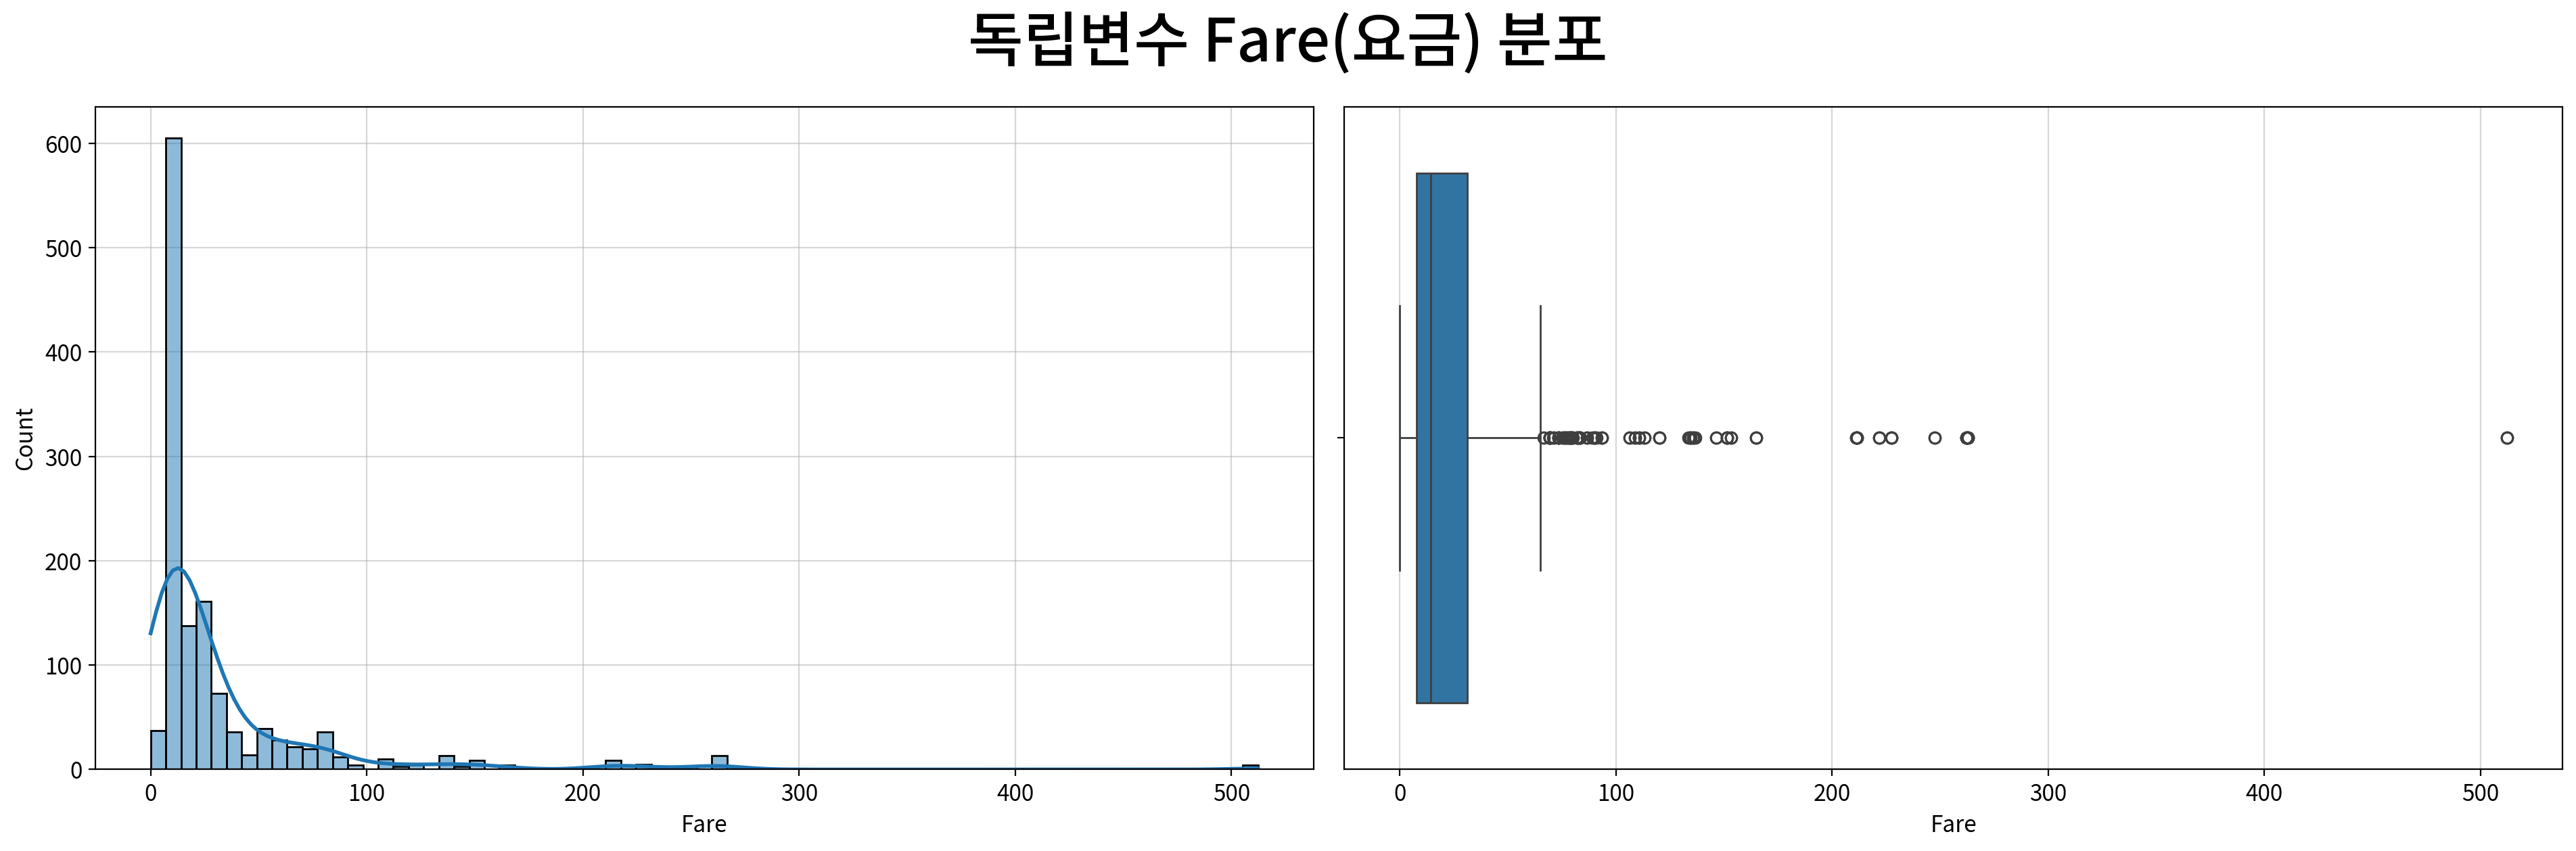

,Fare
count,1309.000
mean,33.281
std,51.741
min,0.000
25%,7.896
50%,14.454
75%,31.275
max,512.329
rel_diff,1.303
rdiff_flag,large_diff


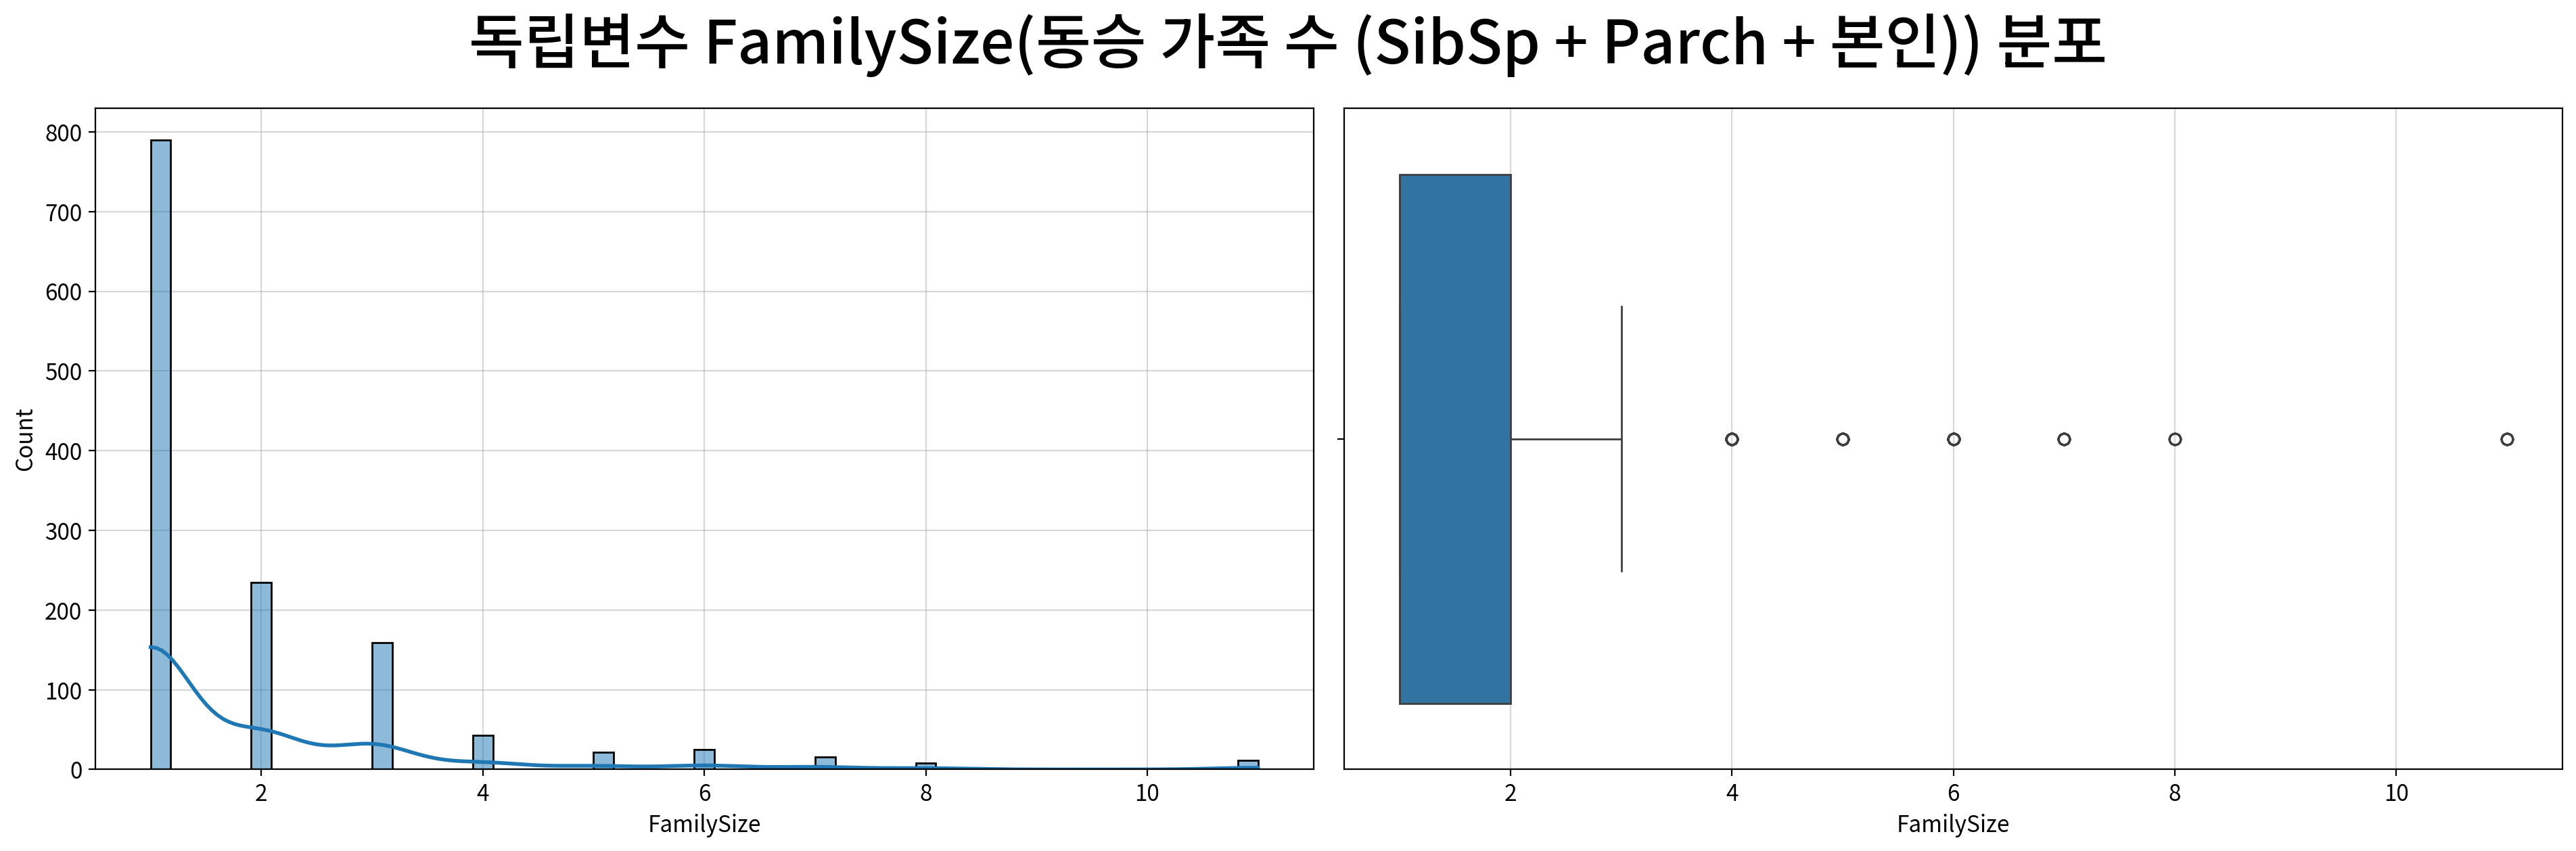

,FamilySize
count,1309.000
mean,1.884
std,1.584
min,1.000
25%,1.000
50%,1.000
75%,2.000
max,11.000
rel_diff,0.884
rdiff_flag,large_diff


In [41]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

#### 💡 인사이트

| 변수 | 분포 모양(왜도) | 봉우리 | 이상치 | 판단·조치 |
|---|---|---|---|---|
| `Age` | 약한 오른쪽 꼬리 (+0.54) | **28세에 인공 봉우리** | 101건 (7.7%) | 중앙값 대체의 흔적. 로짓 선형성 검정에서 재확인 |
| `SibSp` | 심한 오른쪽 꼬리 (+3.84) | 0에 집중 | 57건 (4.4%) | **카운트 변수** — IQR 규칙 부적합 |
| `Parch` | 심한 오른쪽 꼬리 (+3.67) | 0에 집중 | **307건 (23.5%)** | **IQR = 0** → 이상치 판정 자체가 무의미 |
| `Fare` | 극심한 오른쪽 꼬리 (+4.37) | 저가 구간에 집중 | 171건 (13.1%) | 상위 요금은 실제 1등석 가격. 정보이지 오류가 아님 |
| **`FamilySize`** | 오른쪽 꼬리 (+2.85) | **1명에 집중 (60.4%)** | 125건 (9.5%) | **카운트 변수** — IQR = 1이라 4명부터 이상치 |

- **`Age`의 히스토그램 한가운데 뾰족한 막대가 서 있다.** 결측 263건을 중앙값 28세로 채운 자국이다.
  실제 데이터가 아니라 **우리가 만들어 넣은 값**이므로, 이후 결과를 볼 때 항상 염두에 둬야 한다.
- **`Parch`의 상자그림은 상자가 선 하나로 눌려 있다.** Q1 = Q3 = 0이라 상자에 두께가 없다.
  이런 변수에 IQR 이상치 대체를 적용하면 **0이 아닌 값이 전부 0으로 눌려 변수가 상수가 된다.**
- **`FamilySize`는 왜도가 2.85로 원재료보다 완만하다.** (`SibSp` 3.84 · `Parch` 3.67)
  - 둘을 더하면서 0이 몰려 있던 자리가 1로 옮겨가고 분포가 조금 퍼졌기 때문이다.
  - 그래도 **60.4%가 1명(단독 승객)** 이라 여전히 한쪽으로 심하게 쏠려 있다.
  - **IQR = 1이라 상한이 3.5**다. 즉 **가족 4명부터 전부 이상치**로 잡힌다. `Parch`와 같은 함정이므로
    **이상치 대체 대상에서 제외**해야 한다.
- **⚠️ 여기서 로그변환을 하지 않는다.** 로지스틱 회귀는 **독립변수의 정규성을 가정하지 않기** 때문이다.
  왜도가 크다는 사실은 기록해 두되, 변환 여부는 **로짓 선형성 검정**이 결정한다.

## #05. 이변량 분석

### 1. T-Test (x: 연속형 독립변수 → y: 2집단 명목형 종속변수)

#### ▶︎ Age(나이) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   208212.000    0.295        False  0 = 1
                    less        208212.000    0.853        False  0 ≥ 1
                    greater     208212.000    0.147        False  0 ≤ 1

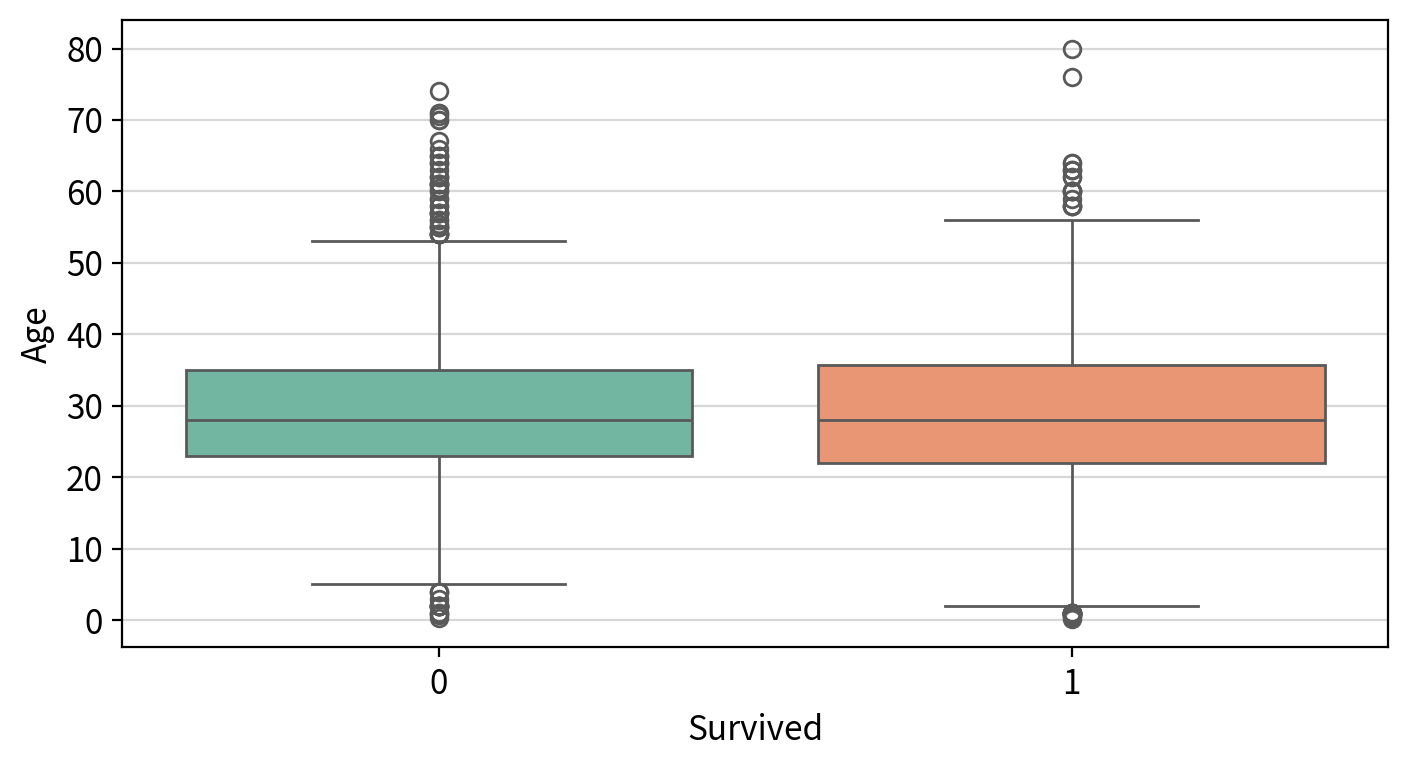

#### ▶︎ SibSp(동승한 형제·배우자 수) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   180053.500    0.000         True  0 ≠ 1
                    less        180053.500    0.000         True  0 < 1
                    greater     180053.500    1.000        False  0 ≤ 1

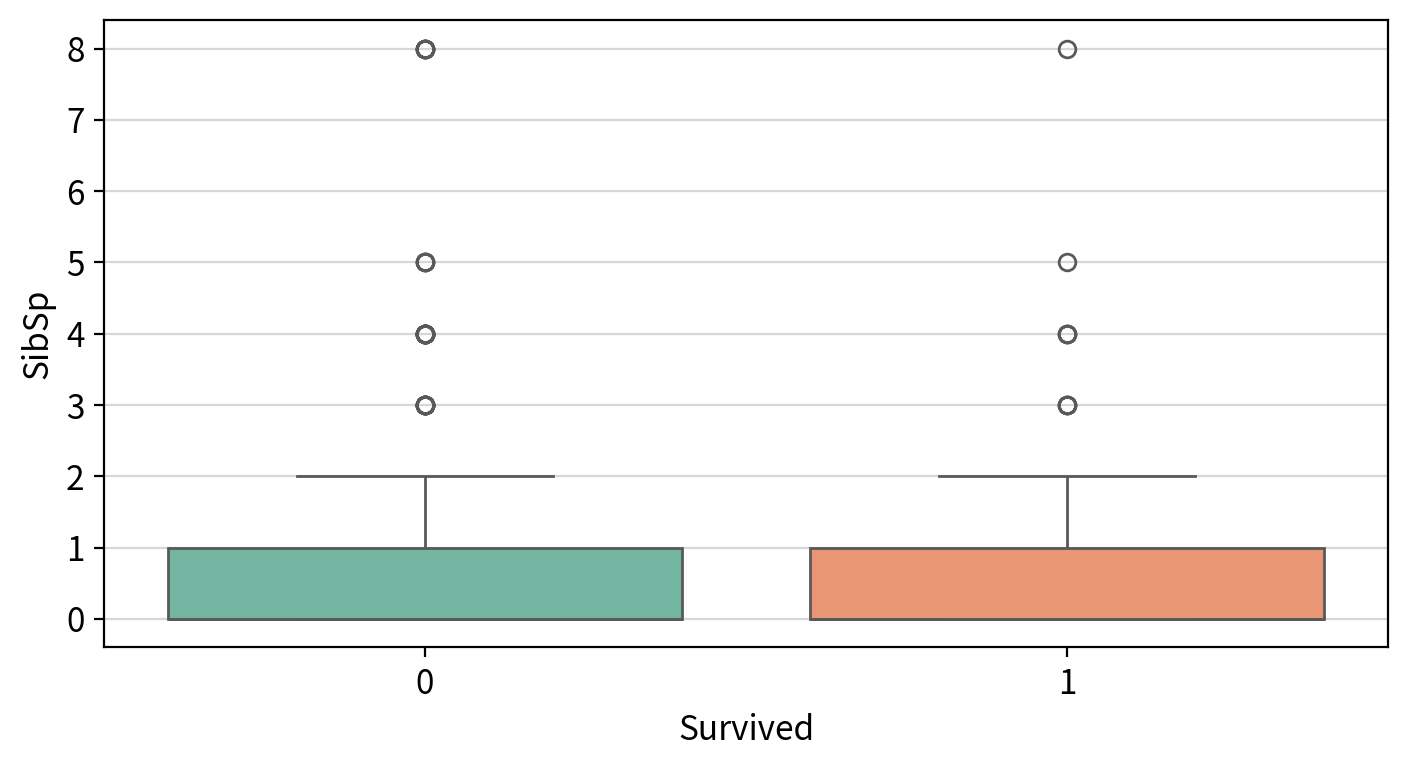

#### ▶︎ Parch(동승한 부모·자녀 수) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   171848.000    0.000         True  0 ≠ 1
                    less        171848.000    0.000         True  0 < 1
                    greater     171848.000    1.000        False  0 ≤ 1

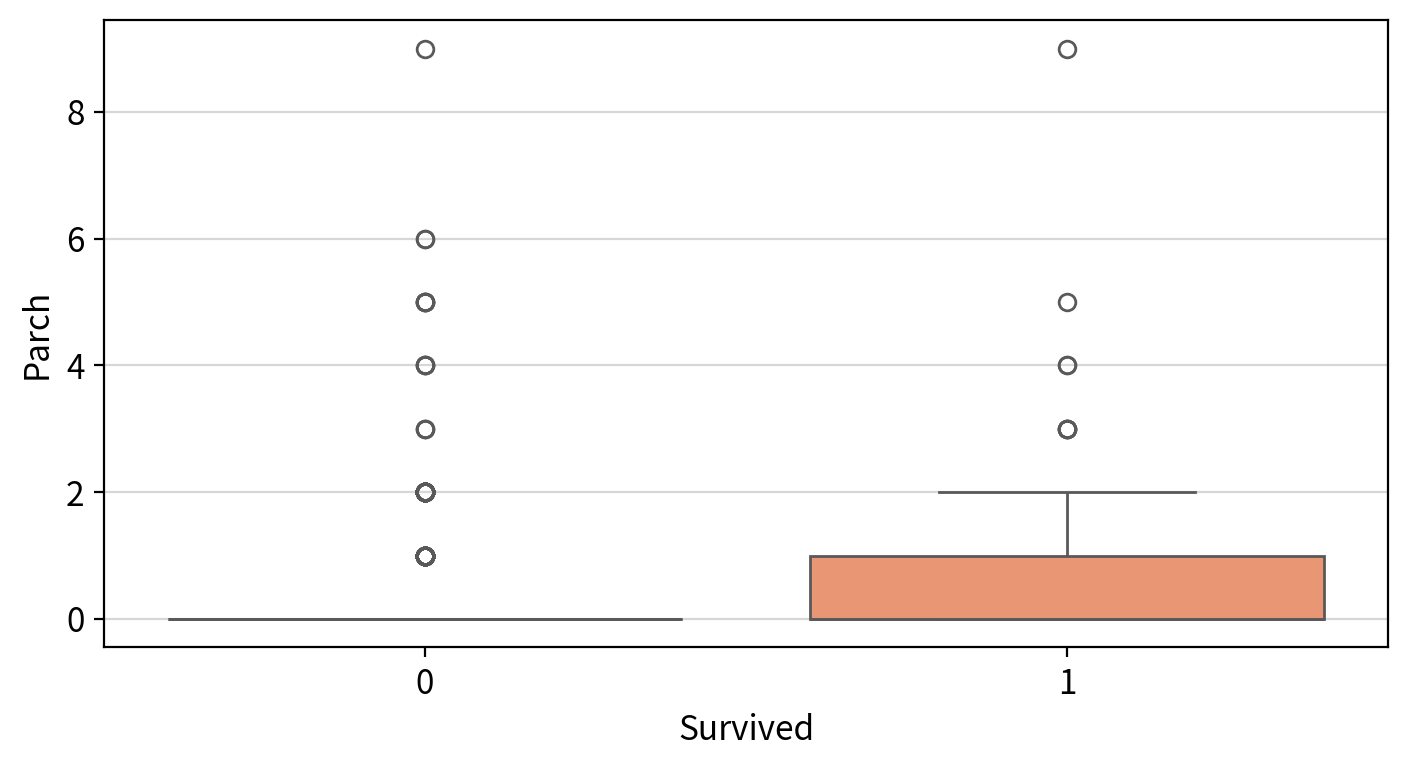

#### ▶︎ Fare(요금) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   132978.000    0.000         True  0 ≠ 1
                    less        132978.000    0.000         True  0 < 1
                    greater     132978.000    1.000        False  0 ≤ 1

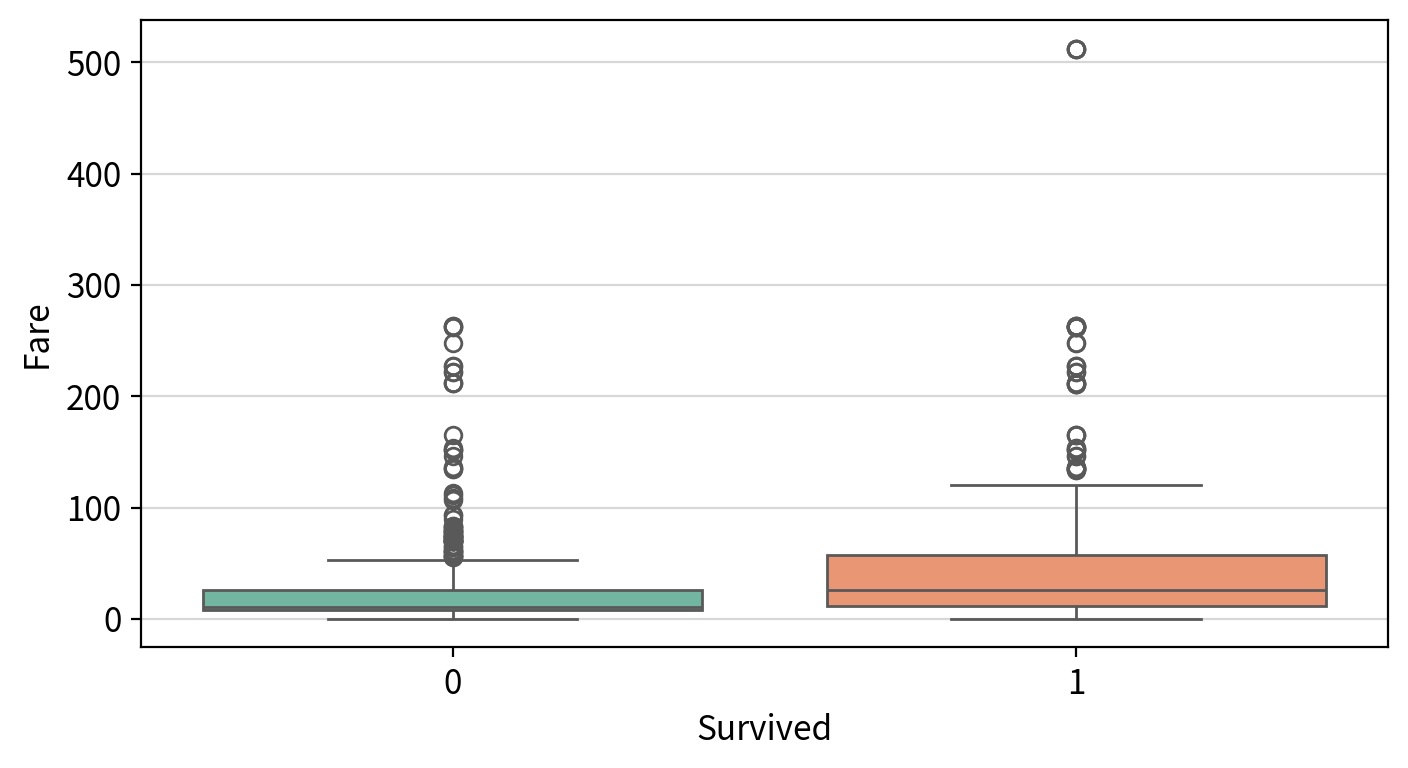

#### ▶︎ FamilySize(동승 가족 수 (SibSp + Parch + 본인)) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   161466.000    0.000         True  0 ≠ 1
                    less        161466.000    0.000         True  0 < 1
                    greater     161466.000    1.000        False  0 ≤ 1

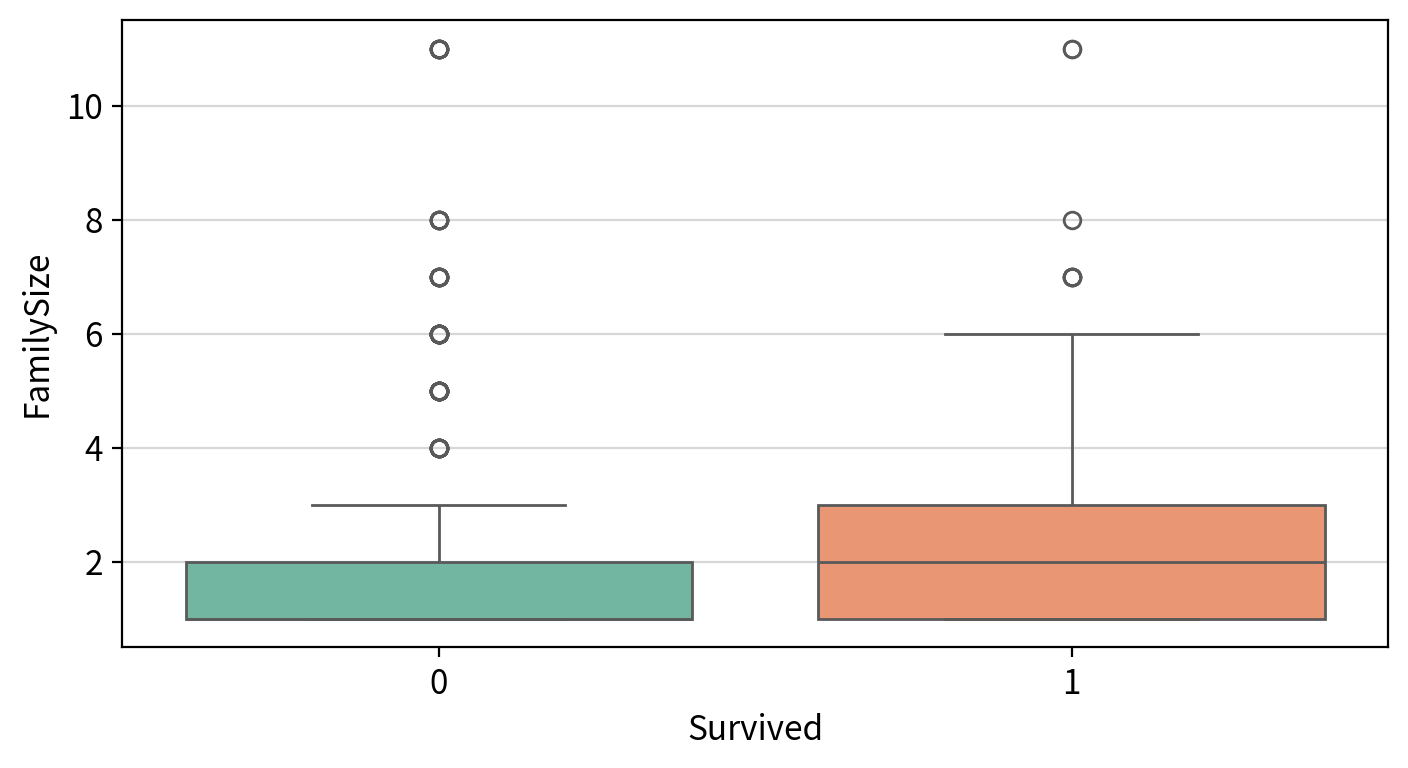

In [42]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))

    # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
    # -> 선형회귀 때와 hue/values 가 서로 뒤바뀐다. (종속변수가 집단 기준이 되므로)
    wide_df = my_prep.long2wide(df, hue=target, values=f)
    display(my_stats.test_independent(wide_df,
                group1=wide_df.columns[0], group2=wide_df.columns[1], plot=False))

    # 시각화: 종속변수 집단별 분포 비교
    my_plot.boxplot(data=df, x=target, y=f, hue=target, palette="Set2",
                    width=720, height=400)

### 2. FamilySize 범주별 분포

- T검정은 두 집단의 **순위 중심 위치**만 비교한다. 즉 "생존자 쪽이 대체로 크다/작다"까지만 말해 준다.
- 그런데 `FamilySize` 는 값이 1~11인 **카운트 변수**라 **값별 생존율의 모양**을 직접 볼 수 있다.
  평균 비교가 놓치는 것이 없는지 확인한다.

,사망률,생존률,인원수
FamilySize,,,
1,0.708,0.292,790
2,0.468,0.532,235
3,0.440,0.560,159
4,0.279,0.721,43
5,0.773,0.227,22
6,0.800,0.200,25
7,0.688,0.312,16
8,0.875,0.125,8
11,0.818,0.182,11


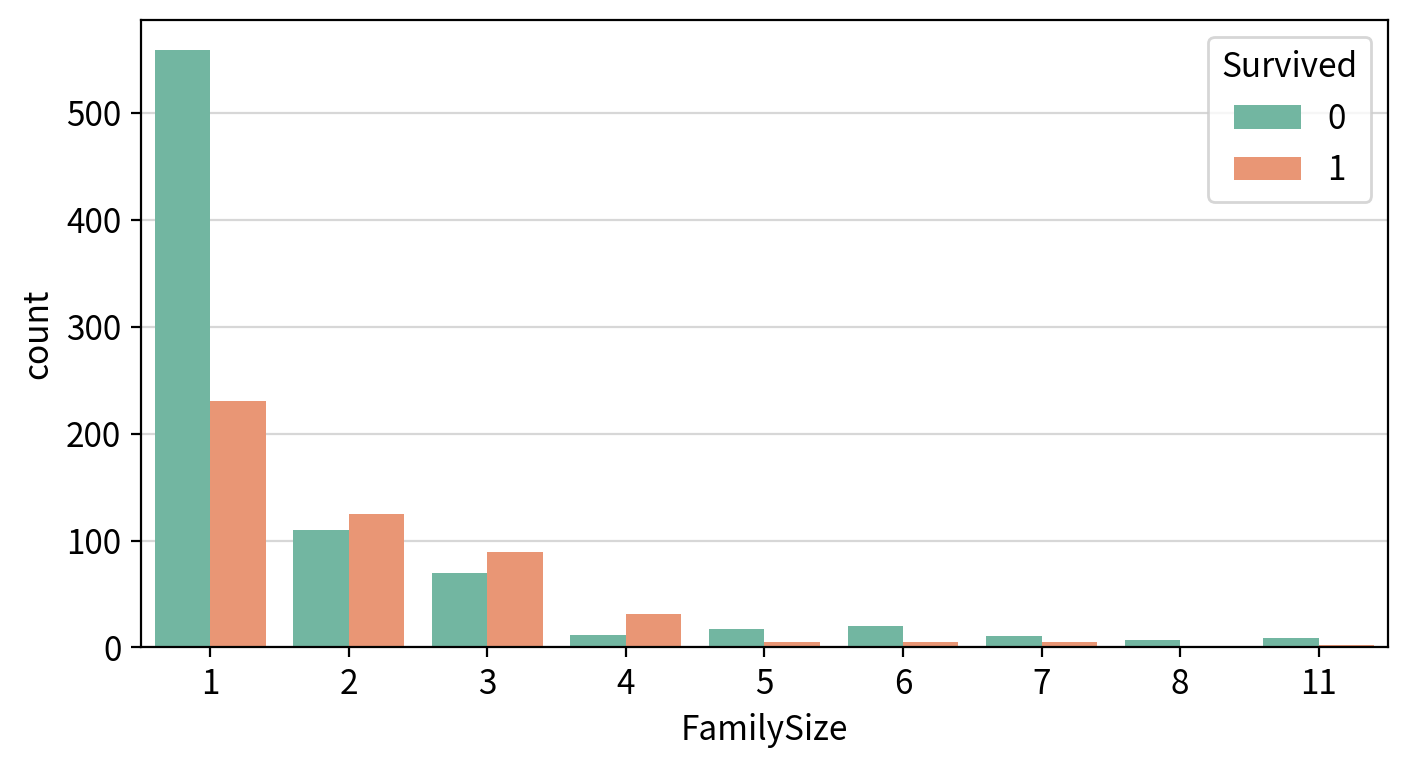

In [43]:
# 가족 규모별 생존율을 직접 계산한다
fs_rate = df.groupby("FamilySize", observed=True)[target].value_counts(normalize=True).unstack()
fs_rate.columns = ["사망률", "생존률"]
fs_rate["인원수"] = df["FamilySize"].value_counts().sort_index()
display(fs_rate)

# 시각화: 가족 규모별 생존 빈도
my_plot.countplot(data=df, x="FamilySize", hue=target, palette="Set2", 
                  width=720, height=400)

#### 💡 인사이트

**5종 모두 정규성이 기각되어 Mann-Whitney U 검정으로 전환**되었다. 사망(0) 집단과 생존(1) 집단의 비교 결과는 다음과 같다.

| 변수 | 검정 방법 | 유의확률 | 집단 차이 | 방향 | 단독 채택 |
|---|---|---|---|---|---|
| `Fare` | Mann-Whitney U | < 0.001 | 유의 | 사망 23.87 < 생존 48.81 | ✅ |
| **`FamilySize`** | Mann-Whitney U | < 0.001 | 유의 | 사망 1.81 < 생존 2.01 | ✅ |
| `Parch` | Mann-Whitney U | < 0.001 | 유의 | 사망 0.31 < 생존 0.51 | ✅ |
| `SibSp` | Mann-Whitney U | < 0.001 | 유의 | 사망 < 생존 | ✅ |
| `Age` | Mann-Whitney U | **0.295** | **차이 없음** | — | 🟡 보류 |

- **`Fare`의 차이가 가장 크다.** 생존자의 평균 요금이 사망자의 **2배**다. 요금은 곧 객실 등급이므로
  이 차이의 상당 부분은 `Pclass`와 겹칠 것으로 예상된다.
- **`SibSp`는 평균이 0.497 대 0.502로 거의 같은데 유의하게 나온다.** 평균이 아니라 **순위 분포**가 다르기 때문이다.
  동승자가 있는 비율이 사망자는 27.2%, 생존자는 39.7%다. 평균만 봐서는 놓치는 차이다.
  - Mann-Whitney U는 평균이 아니라 **순위**를 비교하는 검정이라는 사실이 그대로 드러난 사례다.
- **`FamilySize`도 평균 차이는 0.2명뿐**(1.81 vs 2.01)이지만 유의하다. 같은 이유다.
  - 위의 가족 규모별 생존율 표가 그 이유를 보여준다. **1명 29.2% → 4명 72.1%까지 오르다가
    5명 22.7% → 11명 18.2%로 급락하는 역U자**다. **평균 하나로는 이 모양을 표현할 수 없다.**
  - 양 끝이 서로를 상쇄해 평균 차이가 0.2명으로 줄어든 것이다.
  - → **"유의하다"는 사실보다 "어떻게 유의한가"가 중요하다.**
- **`Age`는 p = 0.295로 무관하게 나온다.** 하지만 이것을 "나이는 생존과 상관없다"로 읽으면 안 된다.
  - 어린이는 우선 구조되어 생존율이 높고, 고령 남성은 생존율이 낮다. **양 끝이 반대 방향이라 평균 비교에서 상쇄**된다.
  - 게다가 결측 263건을 중앙값 28세로 채워 넣어 **두 집단 모두 28세 쪽으로 끌려간 상태**다.
  - → **이 단계의 "무관"은 최종 판정이 아니다.** 기준선 모형에서 다시 확인한다.

### 3. 교차분석 (x: 명목형 독립변수 → y: 명목형 종속변수)

- 명목형 독립변수가 있을 경우 카이제곱 독립성 검정을 수행한다.
  - 명목형 독립변수가 없을 경우 출력 결과가 없을 수 있다.

#### ▶︎ Pclass(객실 등급 (1=1등급, 2=2등급, 3=3등급)) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Pclass,Survived,Chi-square test of independence,91.724,2,0.000,True,0.265,Weak,104.540,True


Survived,0,1
Pclass,,
3,0.731,0.269
2,0.578,0.422
1,0.424,0.576


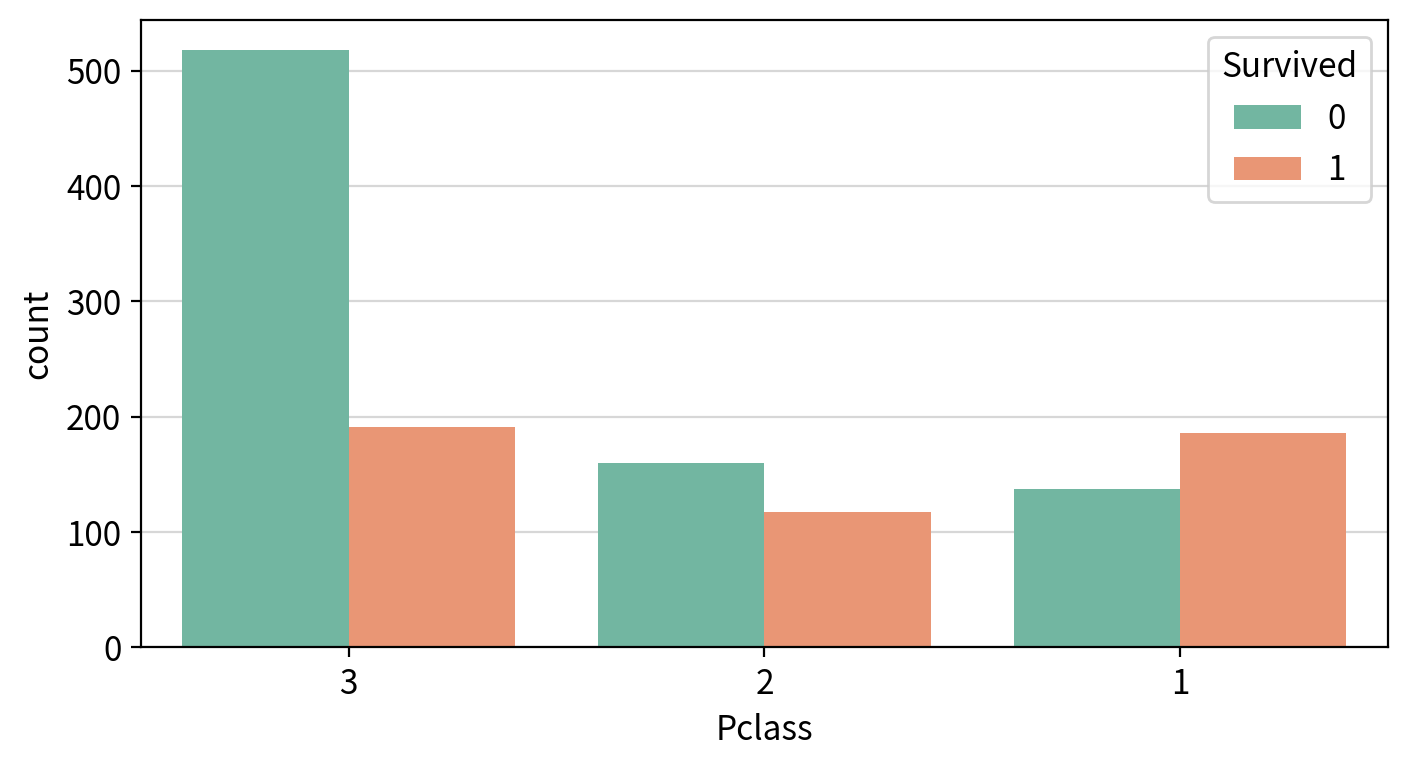

#### ▶︎ Sex(성별) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Sex,Survived,Chi-square test of independence,617.313,1,0.000,True,0.687,Strong,175.860,True


Survived,0,1
Sex,,
female,0.174,0.826
male,0.871,0.129


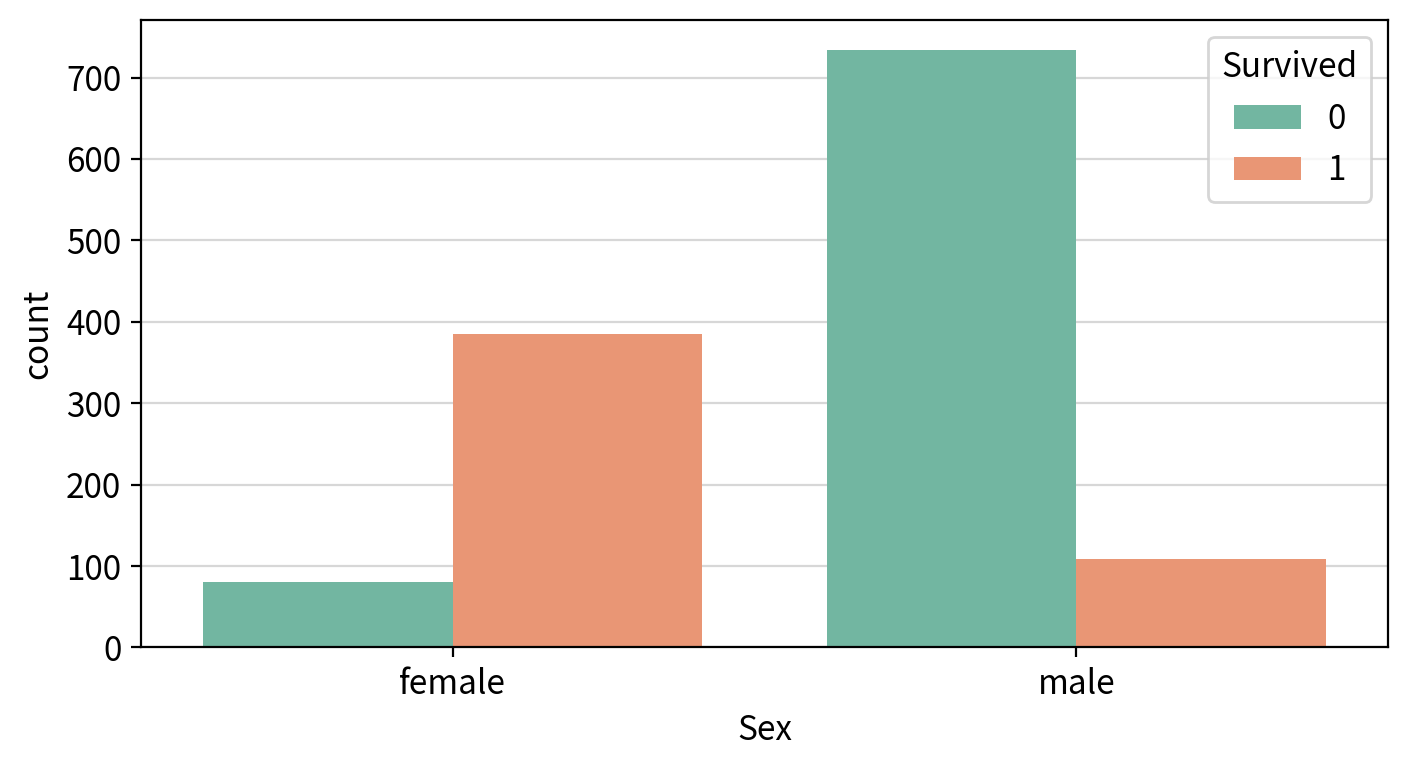

#### ▶︎ Embarked(탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Embarked,Survived,Chi-square test of independence,24.194,2,0.000,True,0.136,Weak,46.420,True


Survived,0,1
Embarked,,
C,0.507,0.493
Q,0.561,0.439
S,0.665,0.335


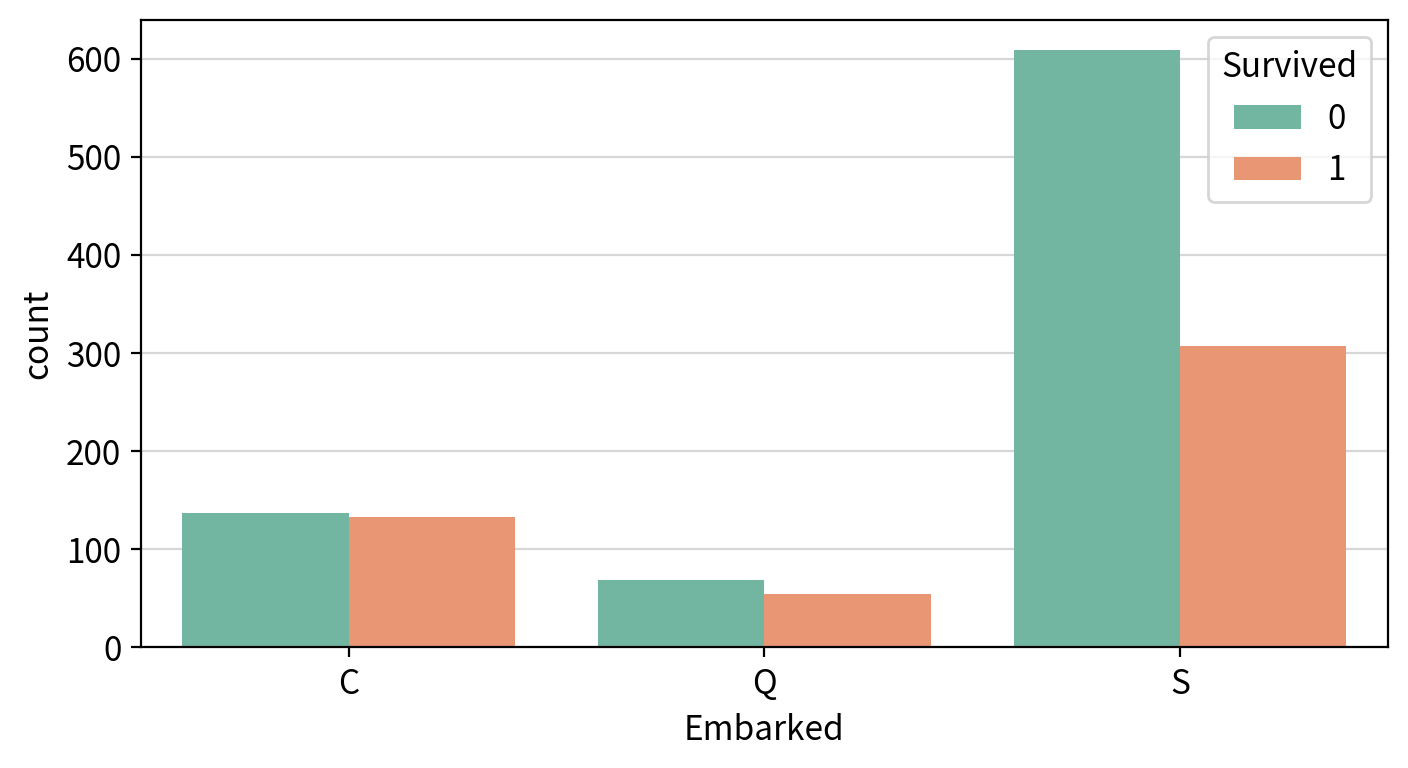

#### ▶︎ Title(이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Title,Survived,Chi-square test of independence,638.384,4,0.000,True,0.698,Strong,8.680,True


Survived,0,1
Title,,
Mr,0.892,0.108
Officer,0.783,0.217
Master,0.623,0.377
Miss,0.208,0.792
Mrs,0.129,0.871


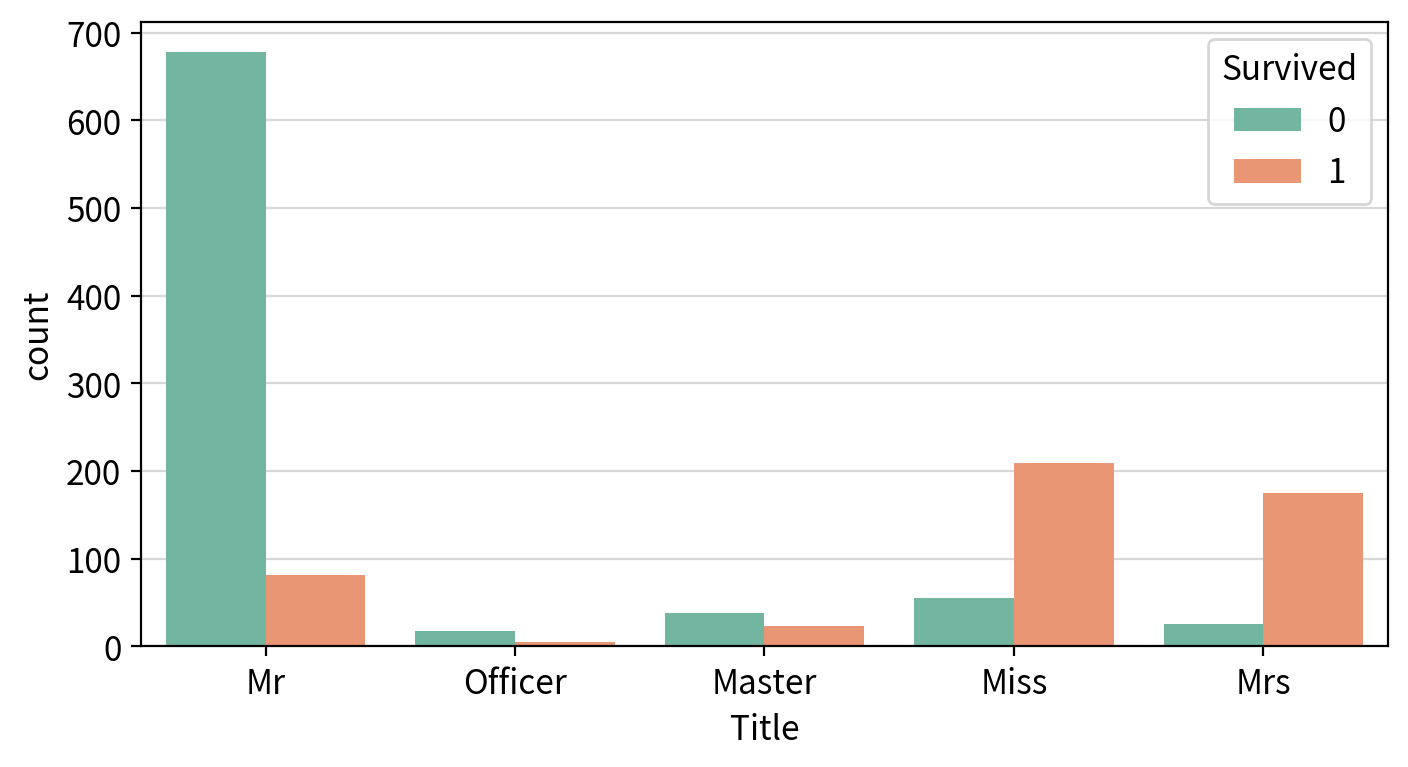

In [44]:
for n in nominal_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

    # 교차분석 (카이제곱 독립성 검정)
    display(my_stats.chi2_independence(df, x=n, y=target, plot=False))

    # 범주별 생존율 표
    rate = df.groupby(n, observed=True)[target].value_counts(normalize=True).unstack()
    display(rate)

    # 시각화: 범주별 생존 비율
    my_plot.countplot(data=df, x=n, hue=target, palette="Set2", width=720, height=400)

#### 💡 인사이트

| 변수 | χ² | 자유도 | 유의확률 | Cramer's V | 효과 크기 | 채택 |
|---|---|---|---|---|---|---|
| **`Title`** | **638.38** | 4 | < 0.001 | **0.698** | **Strong** | ✅ |
| `Sex` | 617.31 | 1 | < 0.001 | 0.687 | **Strong** | ✅ |
| `Pclass` | 91.72 | 2 | < 0.001 | 0.265 | Weak | ✅ |
| `Embarked` | 24.19 | 2 | < 0.001 | 0.136 | Weak | ✅ |

**범주별 생존율**

| 변수 | 범주별 생존율 |
|---|---|
| **`Title`** | **Mrs 87.1% · Miss 79.2% · Master 37.7% · Officer 21.7% · Mr 10.8%** |
| `Sex` | 여성 **82.6%** vs 남성 **12.9%** — 6.4배 차이 |
| `Pclass` | 1등급 57.6% · 2등급 42.2% · 3등급 26.9% — 등급이 낮아질수록 단조 감소 |
| `Embarked` | C 49.3% · Q 43.9% · S 33.5% |

- **`Title`이 `Sex`를 근소하게 앞선다.** χ² 638.38 > 617.31, V 0.698 > 0.687.
  자유도를 4개나 쓰고도 이긴 것이므로 **정보량이 실제로 더 많다**는 뜻이다.
- **차이가 나온 자리는 명확하다. `Master`(남자아이) 37.7%다.**
  - `Sex`는 이 61명을 40세 남성과 똑같은 `male`로 묶었다. 그 집단의 생존율은 12.9%다.
  - `Title`은 이들을 따로 떼어 **37.7%(약 3배)** 를 보여준다.
    **"여성과 어린이 먼저"의 "어린이" 부분이 여기서 처음 드러난다.**
- **`Mrs`(87.1%)와 `Miss`(79.2%)도 갈린다.** `Sex`로는 둘 다 82.6%의 `female`이었다.
  기혼 여성이 미혼 여성보다 생존율이 **7.9%p 높다.** 아이를 동반한 어머니가 우선 구조된 정황이다.
- **`Officer`(21.7%)는 `Mr`(10.8%)의 2배지만 표본이 23명뿐**이다. 해석에 신중해야 한다.
- ⚠️ **`Title`과 `Sex`가 서로 얼마나 겹치는지는 따로 확인해야 한다.**
  #02에서 본 교차표에서 `Mr`·`Master`는 전원 남성, `Miss`·`Mrs`는 전원 여성이었다.
  두 변수를 **함께 쓸 수 있는지는 다변량 분석에서 정량적으로 판정한다.**
- ⚠️ **효과 크기가 Weak라고 해서 버리면 안 된다.** 유의확률은 "관계가 있는가", Cramer's V는 "얼마나 센가"를 말한다.
  둘은 다른 질문이며, 변수 채택은 **다른 변수를 통제한 모형**에서 최종 판정한다.

## #06. 다변량 분석

### 1. 독립변수간 상관 분석

- 연속형 독립변수끼리는 종속변수가 명목형이어도 상관분석을 그대로 쓸 수 있다.
- **파생변수 `FamilySize`가 들어왔으므로 이번 점검은 특히 중요하다.**
  파생변수는 원본 컬럼으로 만든 것이라 **원재료와 겹칠 수밖에 없기 때문**이다.

In [45]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
display(my_stats.correlation_summary(corr))

# 분산팽창지수(VIF)로 한 번 더 확인
display(my_stats.compute_vif(df[continuous_cols]))

/Users/leekh/hossam-ml/helpers/my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
/Users/leekh/hossam-ml/helpers/my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
/Users/leekh/hossam-ml/helpers/my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
/Users/leekh/hossam-ml/helpers/my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


,Age,SibSp,Parch,Fare,FamilySize
Age,1.000,-0.102,-0.182,0.173,-0.135
SibSp,-0.102,1.000,0.438,0.446,0.848
Parch,-0.182,0.438,1.000,0.400,0.796
Fare,0.173,0.446,0.400,1.000,0.521
FamilySize,-0.135,0.848,0.796,0.521,1.000


,max-y,max-coef,count,columns
x,,,,
FamilySize,SibSp,0.848,2,"SibSp, Parch"
SibSp,FamilySize,0.848,1,FamilySize
Parch,FamilySize,0.796,1,FamilySize
Fare,FamilySize,0.521,0,-
Age,Parch,-0.182,0,-


/Users/leekh/.pyenv/versions/3.13.9/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/leekh/.pyenv/versions/3.13.9/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
FamilySize,inf
Parch,inf
SibSp,inf
Fare,1.119
Age,1.099


## #07. 최종 변수 선택

### 1. 변수별 판정

| 채택여부 | 변수 | 검정방법 | 유의확률 | 방향 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|
| ✅ 채택 | **`Title`** | 교차분석 | < 0.001 | Mrs > Miss > Master > Officer > Mr | **`Sex`와 V = 0.998** | V = 0.698 (**Strong**) — 이 데이터 최고 |
| ✅ 채택 | `Sex` | 교차분석 | < 0.001 | 여성 > 남성 | **`Title`과 V = 0.998** | V = 0.687 (Strong) |
| ✅ 채택 | `Pclass` | 교차분석 | < 0.001 | 1등급 > 3등급 | X | 등급 순서대로 단조 감소 |
| ✅ 채택 | `Embarked` | 교차분석 | < 0.001 | C > S | X | 유의하나 `Pclass`와 겹칠 가능성 |
| ✅ 채택 | `Fare` | Mann-Whitney U | < 0.001 | 생존 > 사망 | X (VIF 1.12) | 집단 차이 유의 |
| ✅ 채택 | **`FamilySize`** | Mann-Whitney U | < 0.001 | 생존 > 사망 | **VIF = ∞** | `SibSp`·`Parch`를 합친 변수 |
| ✅ 채택 | `Parch` | Mann-Whitney U | < 0.001 | 생존 > 사망 | **VIF = ∞** | 집단 차이 유의 |
| ✅ 채택 | `SibSp` | Mann-Whitney U | < 0.001 | 생존 > 사망 | **VIF = ∞** | 순위 분포 차이 유의 |
| 🟡 보류 | `Age` | Mann-Whitney U | 0.295 | — | X (VIF 1.10) | 단독 차이는 없으나 **억제효과 가능성** → 투입 후 계수로 판정 |
| ❌ 제외 | `PassengerId` | — | — | — | — | 행마다 값이 다른 **식별자** (#02에서 제거) |
| ❌ 제외 | `Name` | — | — | — | — | 자유 텍스트 — **단, `Title`을 추출한 뒤 제거** (#02) |
| ❌ 제외 | `Ticket` | — | — | — | — | 문자열 식별자 (#02에서 제거) |
| ❌ 제외 | `Cabin` | — | — | — | — | **결측 77.5%** (#02에서 제거) |